## **Importação das bibliotecas e datasets e criação das funções**

In [1]:
import json
import os
import sys
import io
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from keras.layers import Dense,Dropout,SimpleRNN,LSTM #Biblioteca para deep learning
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Configurar a seed para o Python, NumPy e TensorFlow
SEED = 42  # valor fixo que será utilizado como seed

# Seed para o Python
random.seed(SEED)

# Seed para o NumPy (usado para operações de matriz e aleatoriedade fora do TensorFlow)
np.random.seed(SEED)

# Seed para o TensorFlow
tf.random.set_seed(SEED)

In [2]:
base_path = './dataset/'
time_base = 'days'
agrupamento = "7"
dataset_type_du = f"{agrupamento}_days_duas_unas"
#validation_method = 'split'

In [3]:
# Carregar o arquivo JSON
with open('config_pso.json') as f:
    config = json.load(f)

In [4]:
# Cria um diretório específico se não existir
diretorio_pesos_teste_1 = f"Resultados_PSO/pso_du/{agrupamento}_days/pesos/teste_1"
os.makedirs(diretorio_pesos_teste_1, exist_ok=True)

diretorio_pesos_teste_3 = f"Resultados_PSO/pso_du/{agrupamento}_days/pesos/teste_3"
os.makedirs(diretorio_pesos_teste_3, exist_ok=True)

diretorio_avaliacao_teste_0 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_0"
os.makedirs(diretorio_avaliacao_teste_0, exist_ok=True)

diretorio_avaliacao_teste_1 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_1"
os.makedirs(diretorio_avaliacao_teste_1, exist_ok=True)

diretorio_avaliacao_teste_2 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_2"
os.makedirs(diretorio_avaliacao_teste_2, exist_ok=True)

diretorio_avaliacao_teste_3 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_3"
os.makedirs(diretorio_avaliacao_teste_3, exist_ok=True)

diretorio_avaliacao_teste_4 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_4"
os.makedirs(diretorio_avaliacao_teste_4, exist_ok=True)


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
prataI_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
prataII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
prataIII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
pirapama_dataset = f'{base_path}outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

In [6]:
# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset
prataI_df = pd.read_csv(prataI_dataset)  # Transformação em dataset
prataII_df = pd.read_csv(prataII_dataset)  # Transformação em dataset
prataIII_df = pd.read_csv(prataIII_dataset)  # Transformação em dataset
pirapama_df = pd.read_csv(pirapama_dataset)  # Transformação em dataset

In [7]:
validation_interval = config['datasets'][dataset_type_du]['timesteps'] + config['datasets'][dataset_type_du]['output_horizon'] # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
horizonte = config['datasets'][dataset_type_du]['output_horizon']
#print(f'validation interval',validation_interval)

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação

datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]  # df1, df2, etc., são os seus dataframes

# Aplicar MinMaxScaler para cada dataset individualmente
scaled_datasets = []
scalers = []
for i, df in enumerate(datasets):
    # Garantir que 'timestamp' é do tipo datetime e já está configurado corretamente como índice
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(by='timestamp')
        df.set_index('timestamp', inplace=True)

    # Aplicar o scaler apenas nas colunas numéricas
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Apenas colunas numéricas
    scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[float, int]).columns, index=df.index)
    
    # Adicionar o DataFrame escalado à lista
    scaled_datasets.append(scaled_df)
    scalers.append(scaler)  # Salvar o scaler específico para este dataset

# print(scaled_datasets[4].index)
# print(indices_to_validate)

# duas_unas_df_scaled = scaled_datasets[4].iloc[~scaled_datasets[4].index.isin(indices_to_validate)].reset_index(drop=True)
# print(duas_unas_df_scaled)
duas_unas_validation_scaled = scaled_datasets[4].tail(validation_interval)  # Criação do dataset de validação
#print(duas_unas_validation_scaled)
#duas_unas_df_scaled = scaled_datasets[4].drop(tail(indices_to_validate.shape)).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

# Define o número de linhas a serem removidas
X = len(indices_to_validate)
duas_unas_df_scaled = scaled_datasets[4].iloc[:-X]
#print(duas_unas_df_scaled)
# print(duas_unas_validation_scaled)

scaled_datasets[4] = duas_unas_df_scaled

In [8]:
def save_function_output(func, *args, output_file, output_dir, **kwargs):
    # Redireciona stdout para capturar os prints
    old_stdout = sys.stdout
    new_stdout = io.StringIO()
    sys.stdout = new_stdout
    
    try:
        # Executa a função e captura sua saída
        func(*args, **kwargs)
    finally:
        # Restaura stdout e captura a saída
        sys.stdout = old_stdout
        output = new_stdout.getvalue()
        
        # Cria o diretório se não existir
        os.makedirs(output_dir, exist_ok=True)
        
        # Caminho completo para o arquivo de saída
        save_path = os.path.join(output_dir, output_file)
        
        # Salva a saída em um arquivo
        with open(save_path, 'w') as f:
            f.write(output)
        print(f"Output salvo em: {save_path}")

In [9]:
def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [10]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [11]:
def wmse(y_test, y_pred):
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    weights = identify_peaks_and_valleys(y_test)

    wmse_value = (tf.reduce_sum(weights * tf.square(y_test - y_pred)) / tf.reduce_sum(weights))

    return wmse_value

In [12]:

def create_and_train_model(config, dataset_type, X, y, validation_method, k, tt_rate):
    
    model = Sequential()

    for _ in range(int(config['datasets'][dataset_type]['layers'])):
        model.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model.add(Dropout(config['datasets'][dataset_type]['dropout']))

    model.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type]['activation']))

    model.summary()

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type]['optimizer']
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    else:
        opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

    # Aplicar o método de validação
    if validation_method == 'split':
        # Usar validação por divisão
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=tt_rate, random_state=42)
        history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                        callbacks=[early_stopping])
        
        # Ajuste do gráfico para começar em 1
        epochs_range = range(1, len(history.history['loss']) + 1)
        
        plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
        plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
        plt.xlabel('Épocas')
        plt.ylabel('Perda')
        plt.legend()
        plt.show()

    elif validation_method == 'k-fold':
    # Usar validação k-fold
    
        kf = KFold(n_splits=min(k, len(X)), shuffle=False)  # shuffle=False para manter a sequência temporal
        for train_index, val_index in kf.split(X):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]
            history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                            callbacks=[early_stopping])
        
            # Ajuste do gráfico para começar em 1
            epochs_range = range(1, len(history.history['loss']) + 1)

            plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
            plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
            plt.xlabel('Épocas')
            plt.ylabel('Perda')
            plt.legend()
            plt.show()

    return model

In [13]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    
    print("X shape", np.array(X).shape)
    print("y shape", np.array(y).shape)
    return np.array(X), np.array(y)

In [14]:
def concatenate_selected_datasets(datasets, indices):
    
    # Selecionar os datasets pelos índices fornecidos
    selected_datasets = [datasets[i] for i in indices]
    
    # Concatenar os datasets selecionados
    concatenated_df = pd.concat(selected_datasets, ignore_index=True)
    
    # Resetar o índice para uma sequência numérica
    concatenated_df.reset_index(drop=True, inplace=True)
    
    return concatenated_df

In [15]:
# Carregar os pesos salvos
def carregar_pesos(arquivo_pesos_camada):

  with np.load(arquivo_pesos_camada) as data:
      W = data['arr_0']
      U = data['arr_1']
      b = data['arr_2']
      # Os pesos podem ter mais de um conjunto, então você deve garantir que a ordem e o número estejam corretos.
      loaded_weights = [W, U, b]
      print(W.shape)
      print(U.shape)
      print(b.shape)
  return loaded_weights

In [16]:
def carregar_e_aplicar_pesos(lstm_model, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3):
    
    pesos_LSTM1_t1_carregado = carregar_pesos(caminho_LSTM1)
    pesos_LSTM2_t1_carregado = carregar_pesos(caminho_LSTM2)
    #pesos_LSTM3_t1_carregado = carregar_pesos(caminho_LSTM3)

    # Aplicar os pesos carregados à camada LSTM
    lstm_model.get_layer(index=0).set_weights(pesos_LSTM1_t1_carregado)
    lstm_model.get_layer(index=2).set_weights(pesos_LSTM2_t1_carregado)
    #lstm_model.get_layer(index=4).set_weights(pesos_LSTM3_t1_carregado)

In [17]:
# Congela as três primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def congelar_camadas(lstm_model):
#lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = False
    lstm_model.layers[2].trainable = False
    #lstm_model.layers[4].trainable = False
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [18]:
# Descongela as duas primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def descongelar_camadas(lstm_model):
    #lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = True
    lstm_model.layers[2].trainable = True
    #lstm_model.layers[4].trainable = True
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [19]:
# Automatizar os splits de treino/teste
current_filename = None
resultados = []  # Para armazenar os resultados de cada execução
def salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation):
    global current_filename, resultados
    
    # Se o nome do arquivo mudou, salvar os resultados e reiniciar a lista
    if current_filename != diretorio:
        # Atualiza o nome do arquivo atual e reinicia a lista de resultados
        current_filename = diretorio
        resultados = []  # Reinicia a lista de resultados
    
    # Armazenar os resultados
    resultados.append({
        'validation': validation,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'accuracy 2%': acuracia_2,
        'accuracy 5%': acuracia_5,
        'accuracy 10%': acuracia_10,
        'Erro percentual acumulado 30 dias': err_perc_acum_30dias,
        'Erro percentual acumulado 60 dias': err_perc_acum_60dias,
        'Erro percentual acumulado 90 dias': err_perc_acum_90dias,
        'Erro percentual acumulado 1º mês': err_perc_acum_pri_mes,
        'Erro percentual acumulado 2º mês': err_perc_acum_seg_mes,
        'Erro percentual acumulado 3º mês': err_perc_acum_ter_mes
         
        
    })
            
    # Salvar os resultados em um arquivo CSV
    results_df = pd.DataFrame(resultados)
    results_df.to_csv(f'{diretorio}/results.csv', index=False)
    print('Terminada sequencia de testes')

In [ ]:
def avaliacao_multistep(janela_real, janela_prevista, diretorio, validation):

    
    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    # Converte para arrays 1D, se necessário
    janela_real = np.array(janela_real).reshape(-1)
    janela_prevista = np.array(janela_prevista).reshape(-1)
    
    print(janela_real)
    print(" ")
    print(janela_prevista)
    print(" ")

    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)

    # Calcula a acurácia com a contagem de acertos entre 0 e 100%
    acuracia_2 = round(100 * (np.sum(diferencas_percentuais <= 0.02) / len(janela_real)), 2)
    acuracia_5 = round(100 * (np.sum(diferencas_percentuais <= 0.05) / len(janela_real)), 2)
    acuracia_10 = round(100 * (np.sum(diferencas_percentuais <= 0.1) / len(janela_real)), 2)

            
    print("2% Accuracy Score of LSTM model = ",acuracia_2)
    print("5% Accuracy Score of LSTM model = ",acuracia_5)
    print("10% Accuracy Score of LSTM model = ",acuracia_10)
    print(" ")
    
    if agrupamento == '1':
        h_1mes = 30
        h_2mes = 60
        
    elif agrupamento == '3':
        h_1mes = 10
        h_2mes = 20

    else:
        h_1mes = 4
        h_2mes = 8

    acumulado_1mes_real = janela_real[:h_1mes].sum()
    print("acumulado_1mes_real", acumulado_1mes_real)
    acumulado_1e2mes_real = janela_real[:h_2mes].sum()
    print("acumulado_1e2mes_real", acumulado_1e2mes_real)
    acumulado_1e2e3mes_real = janela_real[:].sum()
    print("acumulado_1e2e3mes_real", acumulado_1e2e3mes_real)
    acumulado_2mes_real = janela_real[h_1mes:h_2mes].sum()
    print("acumulado_2mes_real", acumulado_2mes_real)
    acumulado_3mes_real = janela_real[h_2mes:].sum()
    print("acumulado_3mes_real", acumulado_3mes_real)

    acumulado_1mes_pred = janela_prevista[:h_1mes].sum()
    print("acumulado_1mes_pred", acumulado_1mes_pred)
    acumulado_1e2mes_pred = janela_prevista[:h_2mes].sum()
    print("acumulado_1e2mes_pred", acumulado_1e2mes_pred)
    acumulado_1e2e3mes_pred = janela_prevista[:].sum()
    print("acumulado_1e2e3mes_pred", acumulado_1e2e3mes_pred)
    acumulado_2mes_pred = janela_prevista[h_1mes:h_2mes].sum()
    print("acumulado_2mes_pred", acumulado_2mes_pred)
    acumulado_3mes_pred = janela_prevista[h_2mes:].sum()
    print("acumulado_3mes_pred", acumulado_3mes_pred)
    
    err_perc_acum_30dias = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_60dias = round(((abs(acumulado_1e2mes_real-acumulado_1e2mes_pred))/acumulado_1e2mes_real)*100, 2)
    err_perc_acum_90dias = round(((abs(acumulado_1e2e3mes_real-acumulado_1e2e3mes_pred))/acumulado_1e2e3mes_real)*100, 2)
    err_perc_acum_pri_mes = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_seg_mes = round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2)
    err_perc_acum_ter_mes = round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2)

    print("Erro %. acum 30 dias:", err_perc_acum_30dias,"%")
    print("Erro %. acum 60 dias:", err_perc_acum_60dias,"%")
    print("Erro %. acum 90 dias:", err_perc_acum_90dias,"%")
    print(" ")
    print("Erro %. acum 1º mês:", err_perc_acum_pri_mes,"%")
    print("Erro %. acum 2º mês:", err_perc_acum_seg_mes,"%")
    print("Erro %. acum 3º mês:", err_perc_acum_ter_mes,"%")
    
    salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation)
    
    return

In [21]:
def results(model, validation_dataset_scaled, validation_method, diretorio, validation):
    pred = model.predict(validation_dataset_scaled.iloc[0])
    y_pred_rescaled = scalers[4].inverse_transform(pred)
    y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
    duas_unas_validation_rescaled = scalers[4].inverse_transform(validation_dataset_scaled[1:])

    plt.figure(figsize=(14,6))
    plt.plot(validation_dataset_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
    plt.plot(validation_dataset_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
    plt.yticks(np.arange(0,80000,step=10000))
    plt.title("DATASET TESTE")

        # Nome do arquivo incluindo a variável 'validation_method'
    file_name = f'prediction_plot_with_method_{validation_method}_{validation}.png'

    # Caminho completo para salvar o arquivo
    save_path = os.path.join(diretorio, file_name)

    # Salvar o plot
    plt.savefig(save_path)
    plt.show()
    
    
    #avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio, validation)

    # Nome do arquivo incluindo a variável 'validation_method'
    output_file = f'avaliacao_with_method_{validation_method}_{validation}.txt'
    
    save_function_output(avaliacao_multistep, 
                        duas_unas_validation_rescaled, 
                        y_pred_rescaled,
                        diretorio,
                        validation, 
                        output_file = output_file, 
                        output_dir=diretorio)

In [22]:
from tensorflow.keras.initializers import HeNormal
def transfer_learning_model(config, model, diretorio_pesos, diretorio_resultados, teste, validation_method, k):
    
    # Salvamento dos pesos após primeiro treinamento
    pesos_treinamento = model.get_weights()
    pesos_LSTM1 = model.layers[0].get_weights()
    pesos_LSTM2 = model.layers[2].get_weights()
    pesos_LSTM3 = model.layers[4].get_weights()
    pesos_DENSE = model.layers[6].get_weights()

    # Salvar pesos de cada camada LSTM em arquivos .npz
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM1)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM2)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM3)
    np.savez(os.path.join(diretorio_pesos, f'pesos_DENSE_{teste}_{validation_method}_{k}.npz'), *pesos_DENSE)

    # Para salvar os pesos do modelo completo
    np.savez(os.path.join(diretorio_pesos, f'pesos_modelo_{teste}_{validation_method}_{k}.npz'), *pesos_treinamento)

    # # Carregar pesos do arquivo .npz
    # pesos_carregados_LSTM1 = np.load(os.path.join(diretorio, f'pesos_LSTM1_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM2 = np.load(os.path.join(diretorio, f'pesos_LSTM2_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM3 = np.load(os.path.join(diretorio, f'pesos_LSTM3_{teste}_{validation_method}.npz'))
    
    
    X, y = create_dataset(scaled_datasets[4], config['datasets'][dataset_type_du]['timesteps'], config['datasets'][dataset_type_du]['output_horizon'])
    X = X.reshape(X.shape[0], X.shape[1], 1)

    model_ft = Sequential()

    for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
        model_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model_ft.add(Dropout(0.3))

    model_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type_du]['activation']))

    model_ft.summary()
    
    
    # Caminho dos pesos salvos
    caminho_LSTM1 = os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM2 = os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM3 = os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz')

    carregar_e_aplicar_pesos(model_ft, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3)
        
    congelar_camadas(model_ft)
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

    learning_rate = 0.05

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type_du]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model_ft.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=4, restore_best_weights=True) 

    history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])
        
    # Ajuste do gráfico para começar em 1
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()
    
    # descongelar_camadas(model_ft)

    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

    # learning_rate = 0.0008

    # # Configurar o otimizador
    # optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    # if optimizer == 'adam':
    #     opt = Adam(learning_rate=learning_rate)
    # elif optimizer == 'rmsprop':
    #     opt = RMSprop(learning_rate=learning_rate)
    # else:
    #     opt = SGD(learning_rate=learning_rate)

    # # Configurar a função de perda
    # loss_function = config['datasets'][dataset_type_du]["loss_function"]

    # if loss_function == "wmae":
    #     loss = wmae
    # elif loss_function == "wmse":
    #     loss = wmse

    # model_ft.compile(optimizer=opt, loss=loss)

    # early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

    # history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
    #                 callbacks=[early_stopping])
        
    # # Ajuste do gráfico para começar em 1
    # epochs_range = range(1, len(history.history['loss']) + 1)

    # plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    # plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    # plt.xlabel('Épocas')
    # plt.ylabel('Perda')
    # plt.legend()
    plt.show()

    results(model_ft, duas_unas_validation_scaled, validation_method, diretorio_resultados, k)

## **TESTE 00A**
Dataset Duas Unas.

Teste tradicional do modelo sem otimização PSO e treinado apenas pelo dataset Duas Unas.

In [24]:
### DATASETS PARA TESTE 00 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [4]
dataset_test_0A = concatenate_selected_datasets(scaled_datasets, indices)

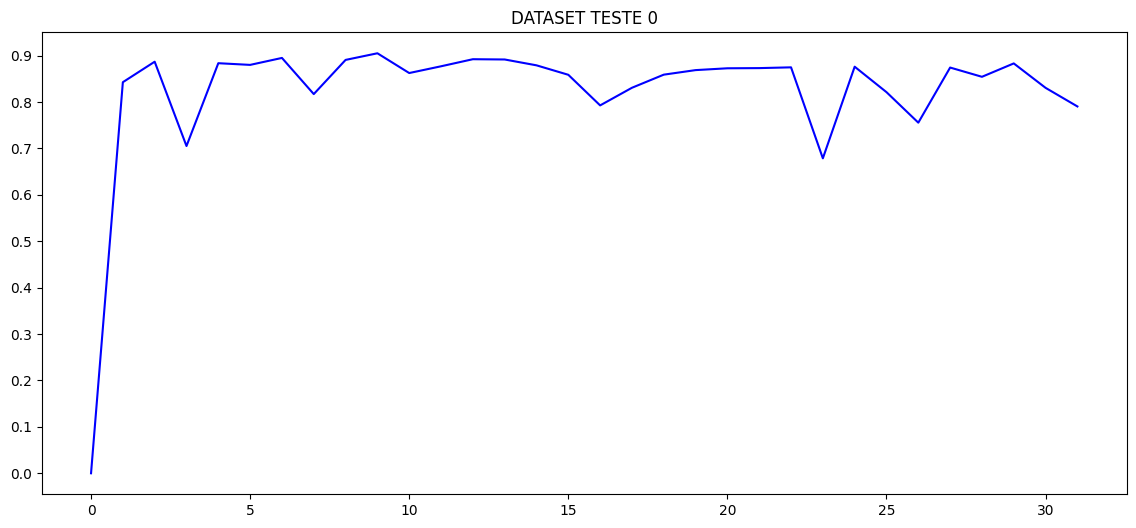

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_0A, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 0")
plt.show()

X shape (20, 1)
y shape (20, 12)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 100)         │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 100)         │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,812 (792.23 KB)

 Trainable params: 202,812 (792.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - loss: 0.7322 - val_loss: 0.6886
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.6945 - val_loss: 0.6342
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.6365 - val_loss: 0.5524
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.5509 - val_loss: 0.4314
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.4185 - val_loss: 0.2675
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.2287 - val_loss: 0.0941
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0592 - val_loss: 0.0755
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.0944 - val_loss: 0.1360
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.2405 - val_loss: 0.0625
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0767 - val_loss: 0.0279
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0194 - val_loss: 0.0427
Epoch 12/100000
1/1 ━━━━━━━━━━━━━━

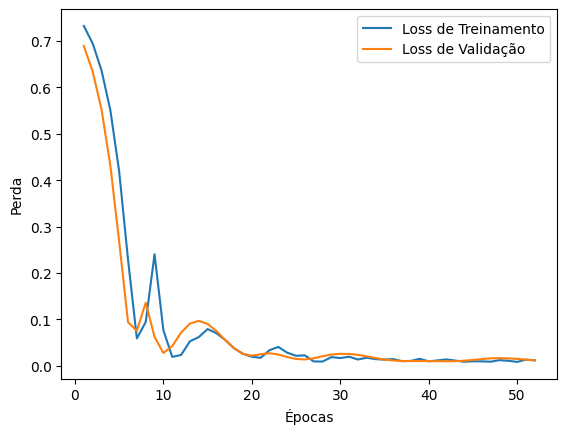

In [26]:
from tensorflow.keras.losses import MeanSquaredError
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_0, y_0 = create_dataset(dataset_test_0A, timesteps, output_steps)
X_0 = X_0.reshape(X_0.shape[0], X_0.shape[1], 1)
X_train, X_test, y_train, y_test = train_test_split(X_0, y_0, test_size=0.2, random_state=42)

model0A = Sequential()

                                                          #X_train.shape[1]
model0A.add(LSTM(100,return_sequences=True, input_shape=(X_0.shape[1], 1))) # Apenas a primeira camada informa input_shape. As demais fazem inferência
model0A.add(Dropout(0.3)) # Taxa de atenuação aplicada à saída para evitar overfitting - Elimina aleatoriamente alguns neurônios

model0A.add(LSTM(100,return_sequences=True))
model0A.add(Dropout(0.3))

model0A.add(LSTM(100,return_sequences=False)) #Anteriormente era FALSE. Foi alterado devido à adição da camada Attention
model0A.add(Dropout(0.3))

model0A.add(Dense(config['datasets'][dataset_type_du]['output_horizon'])) # Dense - Camada totalmente conectada com dimensionalidade de saída igual a 1

model0A.summary() # Printa um sumário da rede

model0A.compile(optimizer=Adam(learning_rate=0.01), loss=MeanSquaredError)

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True)

history = model0A.fit(X_train, y_train, batch_size=16, epochs=100000, validation_data=(X_test, y_test), 
                callbacks=[early_stopping])
    
# Ajuste do gráfico para começar em 1
epochs_range = range(1, len(history.history['loss']) + 1)

plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step


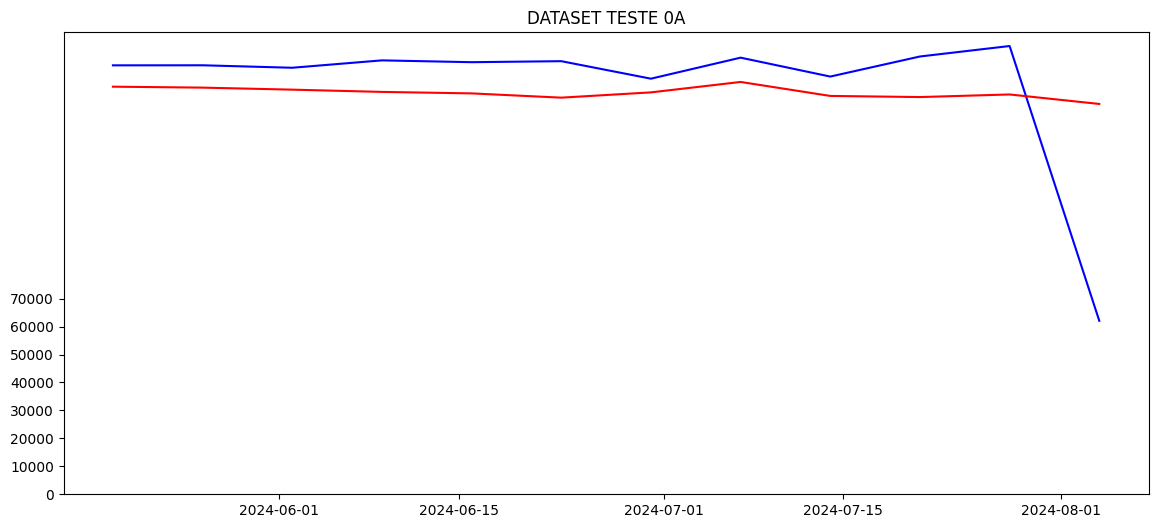

In [27]:
pred_A = model0A.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled_A = scalers[4].inverse_transform(pred_A)
y_pred_rescaled_A = y_pred_rescaled_A.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled_A, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 0A")

# Nome do arquivo incluindo a variável 'name'
file_name = 'prediction_plot_teste_0A.png'

# Caminho completo para salvar o arquivo
save_path = os.path.join(diretorio_avaliacao_teste_0, file_name)

# Salvar o plot
plt.savefig(save_path)
plt.show()

In [28]:
#avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio_avaliacao_teste_0, 'split')

save_function_output(avaliacao_multistep, 
                     duas_unas_validation_rescaled, 
                     y_pred_rescaled_A, 
                     diretorio_avaliacao_teste_0,
                     'split_0A',
                     output_file='avaliacao_teste_0A.txt', 
                     output_dir=diretorio_avaliacao_teste_0)

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_0\avaliacao_teste_0A.txt


## **TESTE 00B**
Dataset Duas Unas.

Teste tradicional do modelo PSO otimizado treinado apenas pelo dataset Duas Unas.

In [24]:
### DATASETS PARA TESTE 00 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [4]
dataset_test_0B = concatenate_selected_datasets(scaled_datasets, indices)


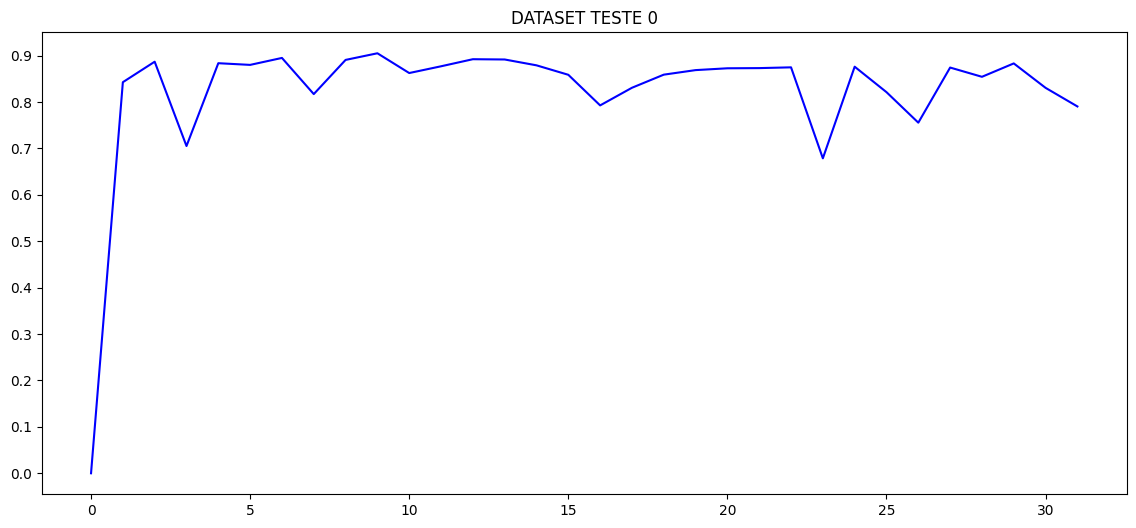

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_0B, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 0")
plt.show()

X shape (20, 1)
y shape (20, 12)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 0.8502 - val_loss: 0.8401
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.8500 - val_loss: 0.8399
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step - loss: 0.8499 - val_loss: 0.8397
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step - loss: 0.8496 - val_loss: 0.8394
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - loss: 0.8493 - val_loss: 0.8391
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.8491 - val_loss: 0.8387
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - loss: 0.8488 - val_loss: 0.8384
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - loss: 0.8484 - val_loss: 0.8380
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.8479 - val_loss: 0.8376
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.8476 - val_loss: 0.8371
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.8470 - val_loss: 0.8367
Epoch 12/100000
1/1 ━━━━━━━━━━━━━━

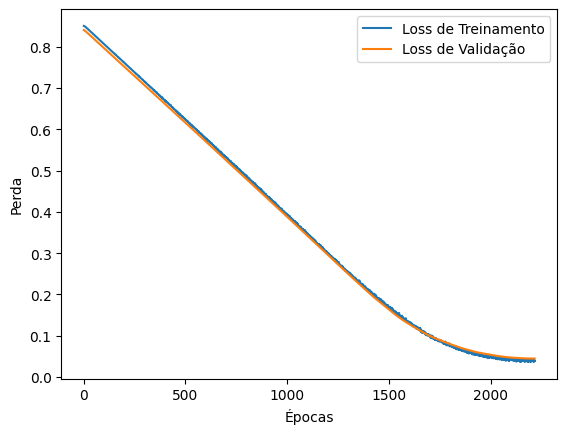

In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_0B, y_0B = create_dataset(dataset_test_0B, timesteps, output_steps)
X_0B = X_0B.reshape(X_0B.shape[0], X_0B.shape[1], 1)
X_trainB, X_testB, y_trainB, y_testB = train_test_split(X_0B, y_0B, test_size=0.2, random_state=42)

model0 = Sequential()

for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
    model0.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                    #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                    return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X_0B.shape[1], 1)))

    model0.add(Dropout(config['datasets'][dataset_type_du]['dropout']))

model0.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                    activation=config['datasets'][dataset_type_du]['activation']))

model0.summary()

# Configurar o otimizador
optimizer = config['datasets'][dataset_type_du]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])
else:
    opt = SGD(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])

# Configurar a função de perda
loss_function = config['datasets'][dataset_type_du]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model0.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type_du]['patience'], restore_best_weights=True)

history = model0.fit(X_trainB, y_trainB, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_testB, y_testB), 
                callbacks=[early_stopping])
    
# Ajuste do gráfico para começar em 1
epochs_range = range(1, len(history.history['loss']) + 1)

plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


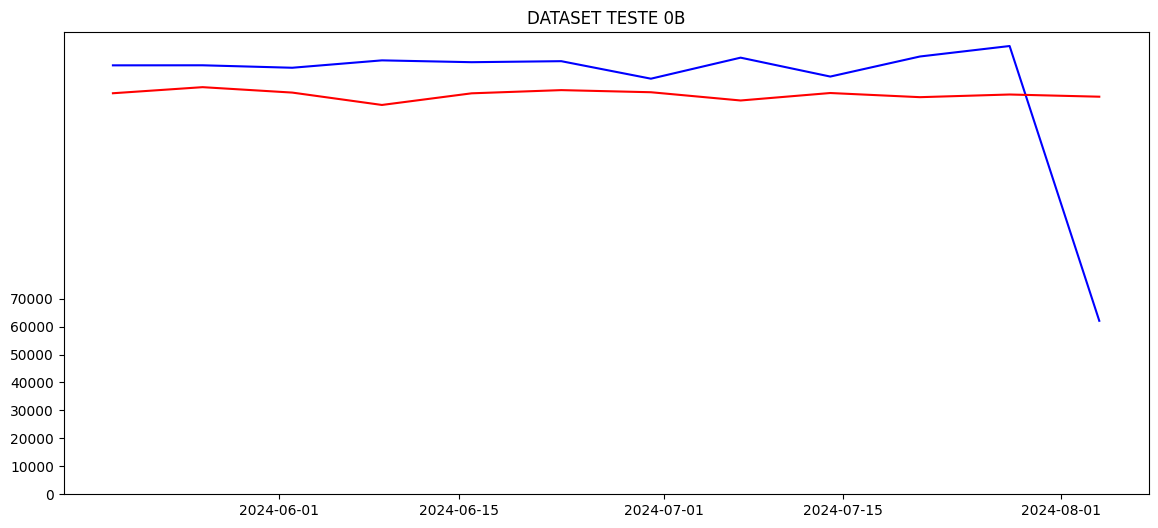

In [27]:
pred_B = model0.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled_B = scalers[4].inverse_transform(pred_B)
y_pred_rescaled_B = y_pred_rescaled_B.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled_B = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled_B, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled_B, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 0B")

# Nome do arquivo incluindo a variável 'name'
file_name = 'prediction_plot_teste_0B.png'

# Caminho completo para salvar o arquivo
save_path = os.path.join(diretorio_avaliacao_teste_0, file_name)

# Salvar o plot
plt.savefig(save_path)
plt.show()

In [28]:
#avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio_avaliacao_teste_0, 'split')

save_function_output(avaliacao_multistep, 
                     duas_unas_validation_rescaled_B, 
                     y_pred_rescaled_B, 
                     diretorio_avaliacao_teste_0,
                     'split_0B',
                     output_file='avaliacao_teste_0B.txt', 
                     output_dir=diretorio_avaliacao_teste_0)

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_0\avaliacao_teste_0B.txt


## **TESTE 01**
Prata I, II, III e Duas Unas.
Ações a serem testadas:

0. Validar se a técnica de TL que envolve congelamento de camadas é reconhecido e amplamente utilizado;
1. Padronizar cada dataset em separado (Prata I, II, III);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [23]:
### DATASETS PARA TESTE 01 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [1, 2, 3]
dataset_test_1 = concatenate_selected_datasets(scaled_datasets, indices)

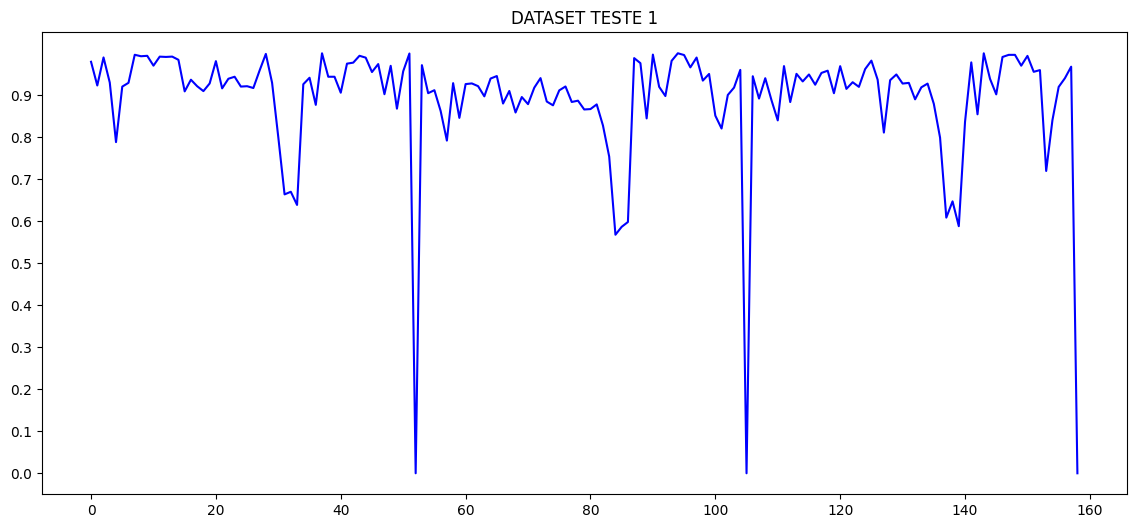

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_1, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_1, y_1 = create_dataset(dataset_test_1, timesteps, output_steps)
X_1 = X_1.reshape(X_1.shape[0], X_1.shape[1], 1)

#model1 = create_model(config, dataset_type_du, X_1, y_1,validation_method, 4)

X shape (147, 1)
y shape (147, 12)



Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.8898 - val_loss: 0.8606
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.8793 - val_loss: 0.8481
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.8666 - val_loss: 0.8357
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.8540 - val_loss: 0.8232
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.8413 - val_loss: 0.8107
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.8287 - val_loss: 0.7983
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.8161 - val_loss: 0.7858
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8035 - val_loss: 0.7734
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7909 - val_loss: 0.7609
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7781 - val_loss: 0.7484
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7656 - val_loss: 0.7360
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s

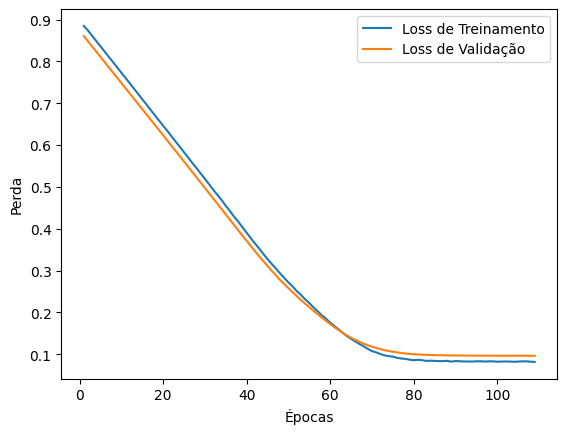

X shape (20, 1)
y shape (20, 12)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.8510 - val_loss: 0.8471
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - loss: 0.8492 - val_loss: 0.8438
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step - loss: 0.8458 - val_loss: 0.8397
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.8420 - val_loss: 0.8356
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.8377 - val_loss: 0.8314
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 0.8330 - val_loss: 0.8271
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.8292 - val_loss: 0.8229
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.8244 - val_loss: 0.8187
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.8203 - val_loss: 0.8144
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.8155 - val_loss: 0.8102
Epoch 11/100000
1/1 

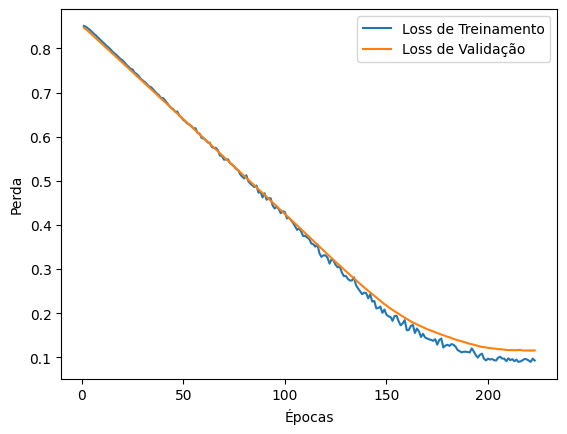

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step


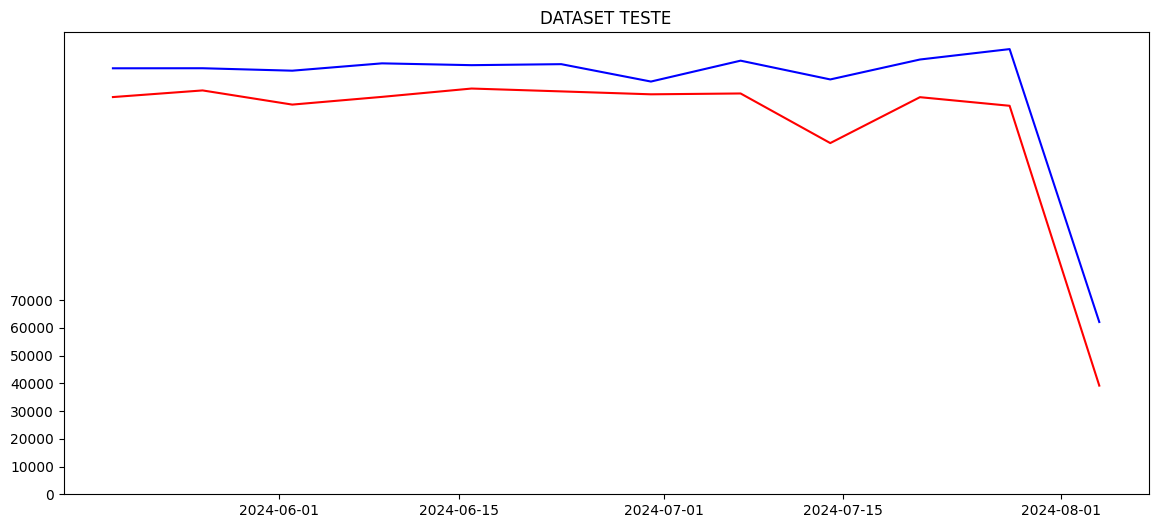

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.1.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.8893 - val_loss: 0.8708
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8792 - val_loss: 0.8577
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.8662 - val_loss: 0.8447
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8534 - val_loss: 0.8317
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8405 - val_loss: 0.8186
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.8277 - val_loss: 0.8056
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.8148 - val_loss: 0.7926
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.8019 - val_loss: 0.7795
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.7892 - val_loss: 0.7665
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.7764 - val_loss: 0.7534
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.7633 - val_loss: 0.7404
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

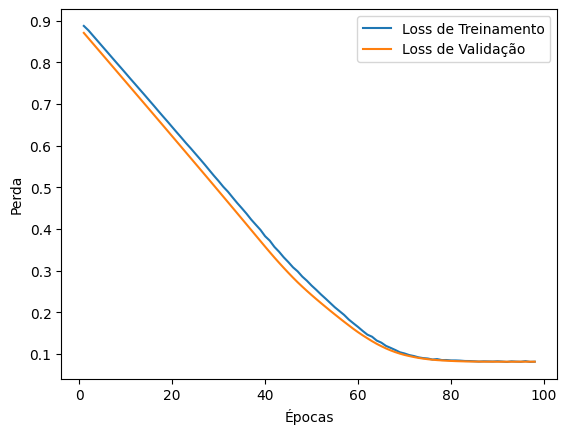

X shape (20, 1)
y shape (20, 12)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - loss: 0.8510 - val_loss: 0.8467
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step - loss: 0.8487 - val_loss: 0.8432
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.8453 - val_loss: 0.8390
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.8412 - val_loss: 0.8345
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.8361 - val_loss: 0.8299
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.8312 - val_loss: 0.8253
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.8266 - val_loss: 0.8206
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.8222 - val_loss: 0.8160
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.8171 - val_loss: 0.8114
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.8135 - val_loss: 0.8069
Epoch 11/100000
1/1

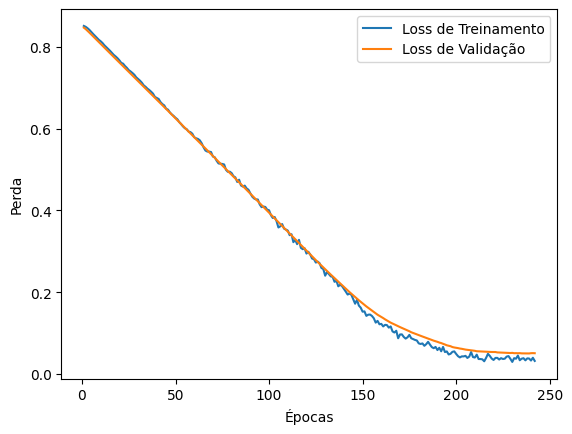

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


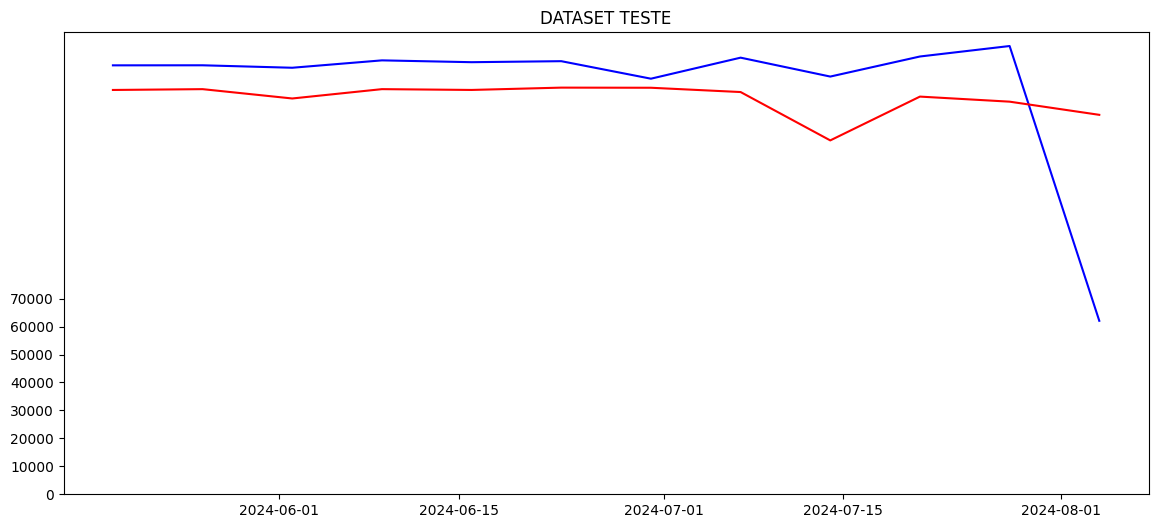

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.2.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: 0.8905 - val_loss: 0.8748
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.8795 - val_loss: 0.8618
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8665 - val_loss: 0.8487
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.8536 - val_loss: 0.8357
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.8407 - val_loss: 0.8226
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8278 - val_loss: 0.8096
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8147 - val_loss: 0.7966
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.8019 - val_loss: 0.7835
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.7887 - val_loss: 0.7705
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.7760 - val_loss: 0.7574
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.7631 - val_loss: 0.7444
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

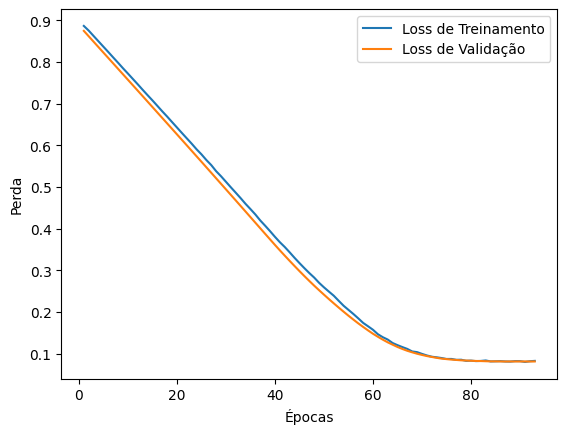

X shape (20, 1)
y shape (20, 12)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - loss: 0.8508 - val_loss: 0.8464
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 0.8493 - val_loss: 0.8430
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.8452 - val_loss: 0.8387
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.8415 - val_loss: 0.8346
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.8368 - val_loss: 0.8301
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.8320 - val_loss: 0.8256
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.8280 - val_loss: 0.8210
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.8232 - val_loss: 0.8163
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8184 - val_loss: 0.8116
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8132 - val_loss: 0.8068
Epoch 11/100000
1/1

In [ ]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model1 = create_and_train_model(config, dataset_type_du, X_1, y_1, validation_method, k=k, tt_rate=0)
#     transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, str(k))
    
# Treinamento com train-test split
tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    print("\nTraining with train-test split")
    validation_method = 'split'
    model1 = create_and_train_model(config, dataset_type_du, X_1, y_1, validation_method, None, tt_rate)
    transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, tt_rate)



# # Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model3 = train_model(X_3, y_3, validation_method, k, tt_rate=0)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3, 'teste_3', validation_method, str(k))
    
# # Treinamento com train-test split
# tt_rate = 0
# for k in range(1,10):
#     tt_rate += 0.10
#     print("\nTraining with train-test split")
#     validation_method = 'split'
#     model3 = train_model(X_3, y_3, validation_method, None, tt_rate)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3,'teste_3', validation_method, tt_rate)

In [ ]:
# #model1 = create_model(config, dataset_type_du, X_1, y_1,validation_method, 4)
# for k in range(2,9):
#     model1 = create_model(config, dataset_type_du, X_1, y_1, 'k-fold', k)
#     results(model1, duas_unas_validation_scaled, validation_method, diretorio_avaliacao_teste_1, k)

# model1 = create_model(config, dataset_type_du, X_1, y_1, 'split', 0)
# results(model1, duas_unas_validation_scaled, validation_method, diretorio_avaliacao_teste_1, 'split')

In [ ]:
# # Salvamento dos pesos após primeiro treinamento

# pesos_treinamento1 = model1.get_weights()
# pesos_LSTM1_t1 = model1.layers[0].get_weights()
# pesos_LSTM2_t1 = model1.layers[2].get_weights()
# pesos_LSTM3_t1 = model1.layers[4].get_weights()
# pesos_DENSE_t1 = model1.layers[6].get_weights()

# # Salvar pesos de cada camada LSTM em arquivos .npz
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz'), *pesos_LSTM1_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz'), *pesos_LSTM2_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz'), *pesos_LSTM3_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_DENSE_t1_{validation_method}.npz'), *pesos_DENSE_t1)

# # Para salvar os pesos do modelo completo
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_modelo_t1_{validation_method}.npz'), *pesos_treinamento1)

# # Carregar pesos do arquivo .npz
# pesos_carregados_LSTM1_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz'))
# pesos_carregados_LSTM2_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz'))
# pesos_carregados_LSTM3_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz'))

In [ ]:
# X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
# X = X.reshape(X.shape[0], X.shape[1], 1)

# model1_ft = Sequential()

# for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
#     model1_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os bias
#                     return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

#     model1_ft.add(Dropout(0.3))

# model1_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os biases
#                     activation=config['datasets'][dataset_type_du]['activation']))

# model1_ft.summary()

In [ ]:
# # Caminho dos pesos salvos
# caminho_LSTM1_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz')
# caminho_LSTM2_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz')
# caminho_LSTM3_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz')

# carregar_e_aplicar_pesos(model1_ft, caminho_LSTM1_t1, caminho_LSTM2_t1, caminho_LSTM3_t1)

In [ ]:
# # Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

# ### CAMADA LSTM 1
# sao_iguais1 = np.array_equal(pesos_LSTM1_t1[0], model1_ft.layers[0].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM1_t1[1], model1_ft.layers[0].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM1_t1[2], model1_ft.layers[0].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 2
# sao_iguais1 = np.array_equal(pesos_LSTM2_t1[0], model1_ft.layers[2].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM2_t1[1], model1_ft.layers[2].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM2_t1[2], model1_ft.layers[2].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 3
# # sao_iguais1 = np.array_equal(pesos_LSTM3_t1[0], model1_ft.layers[4].get_weights()[0])
# # sao_iguais2 = np.array_equal(pesos_LSTM3_t1[1], model1_ft.layers[4].get_weights()[1])
# # sao_iguais3 = np.array_equal(pesos_LSTM3_t1[2], model1_ft.layers[4].get_weights()[2])

# # print(sao_iguais1)
# # print(sao_iguais2)
# # print(sao_iguais3)


In [ ]:
# congelar_camadas(model1_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

# learning_rate = 0.005

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model1_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [ ]:
# descongelar_camadas(model1_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

# learning_rate = 0.0008

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model1_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [ ]:
# pred = model1_ft.predict(duas_unas_validation_scaled.iloc[0])
# y_pred_rescaled = scalers[4].inverse_transform(pred)
# y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
# duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

# plt.figure(figsize=(14,6))
# plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
# plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
# plt.yticks(np.arange(0,80000,step=10000))
# plt.title("DATASET TESTE 1")

# # Nome do arquivo incluindo a variável 'validation_method'
# file_name = f'prediction_plot_with_method_{validation_method}.png'

# # Caminho completo para salvar o arquivo
# save_path = os.path.join(diretorio_avaliacao_teste_1, file_name)

# # Salvar o plot
# plt.savefig(save_path)
# plt.show()

In [ ]:
# avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

# # Nome do arquivo incluindo a variável 'validation_method'
# output_file = f'avaliacao_with_method_{validation_method}.txt'

# save_function_output(avaliacao_multistep, 
#                      duas_unas_validation_rescaled, 
#                      y_pred_rescaled, 
#                      output_file = output_file, 
#                      output_dir=diretorio_avaliacao_teste_1)

## **TESTE 02**

Prata I, II, III e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [24]:
### DATASETS PARA TESTE 02 ###

indices = [1, 2, 3, 4]
dataset_test_2 = concatenate_selected_datasets(scaled_datasets, indices)

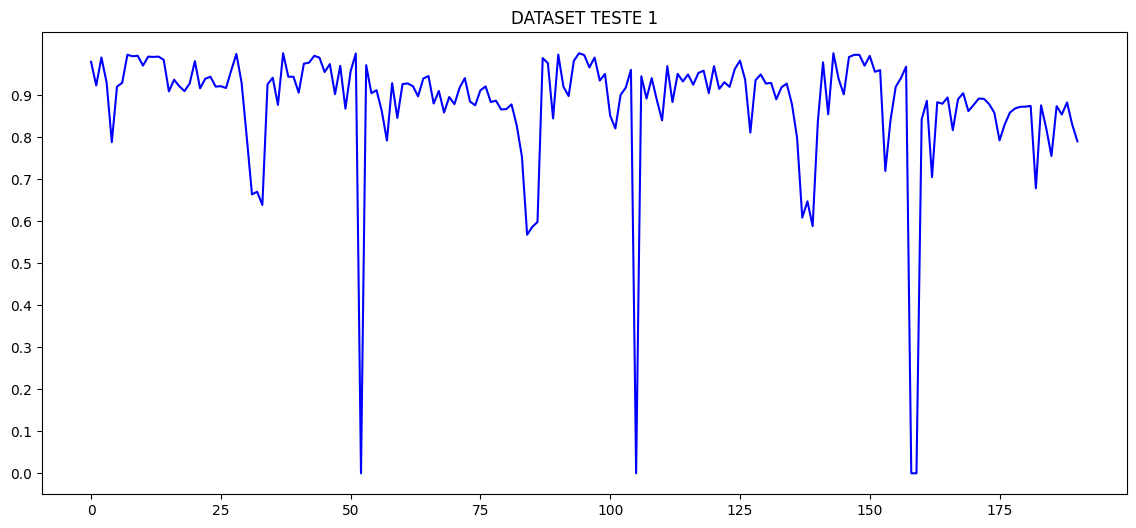

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_2, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X, y = create_dataset(dataset_test_2, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

X shape (179, 1)
y shape (179, 12)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - loss: 0.8744 - val_loss: 0.8670
Epoch 2/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.8601 - val_loss: 0.8507
Epoch 3/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.8440 - val_loss: 0.8343
Epoch 4/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8279 - val_loss: 0.8179
Epoch 5/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8118 - val_loss: 0.8016
Epoch 6/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.7957 - val_loss: 0.7852
Epoch 7/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7798 - val_loss: 0.7689
Epoch 8/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7637 - val_loss: 0.7525
Epoch 9/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7477 - val_loss: 0.7361
Epoch 10/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7315 - val_loss: 0.7197
Epoch 11/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7154 - val_loss: 0.7033
Epoch 12/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0

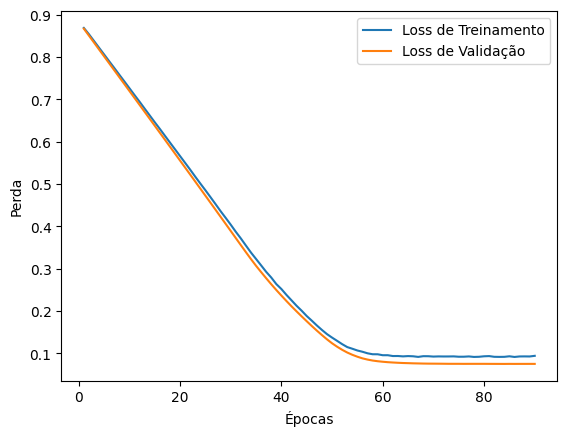

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


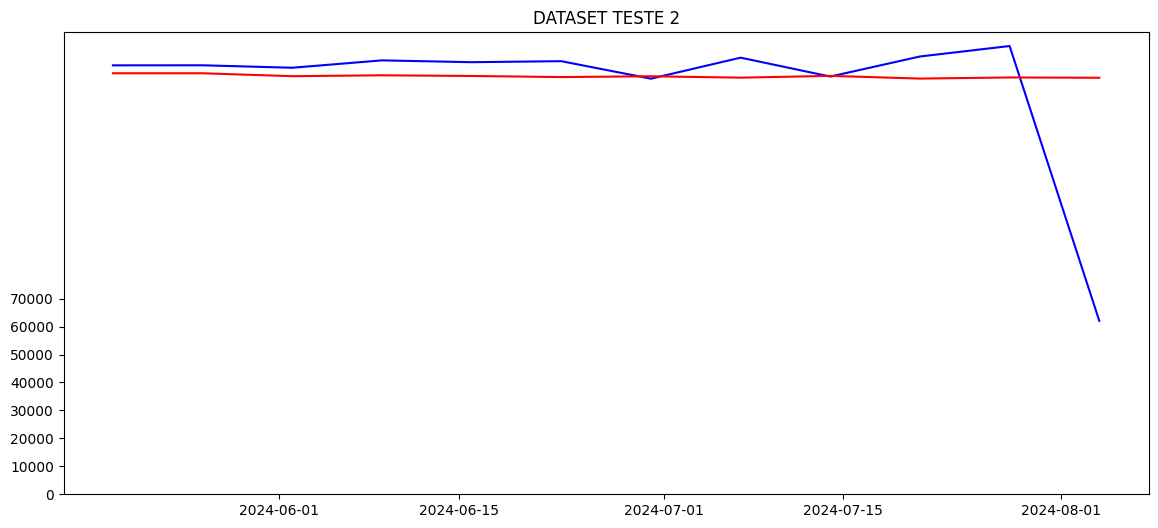

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.1.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - loss: 0.8673 - val_loss: 0.8690
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.8588 - val_loss: 0.8568
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.8468 - val_loss: 0.8446
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.8349 - val_loss: 0.8324
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.8229 - val_loss: 0.8202
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.8109 - val_loss: 0.8080
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.7990 - val_loss: 0.7958
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.7869 - val_loss: 0.7835
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.7750 - val_loss: 0.7713
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.7632 - val_loss: 0.7591
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.7511 - val_loss: 0.7469
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━

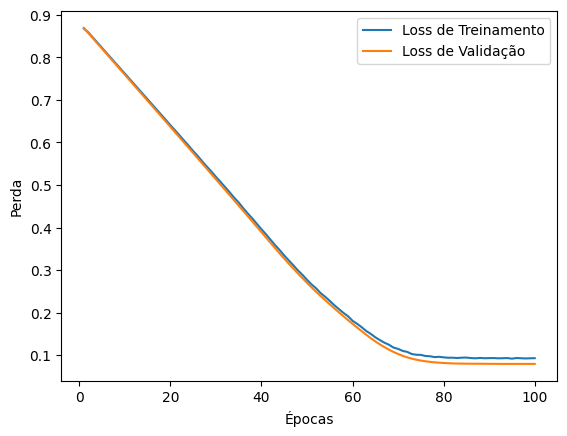

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


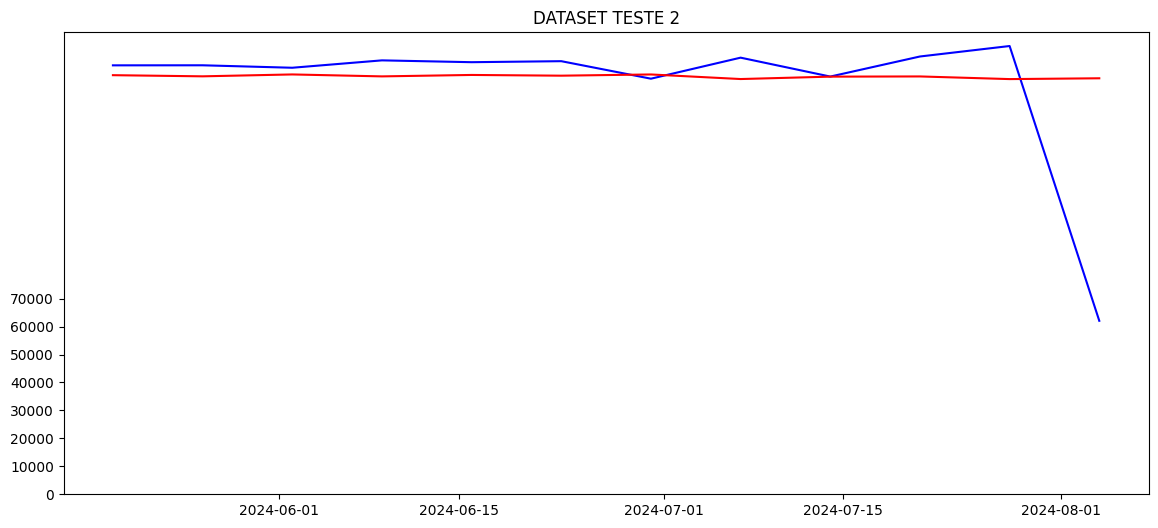

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.2.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.8730 - val_loss: 0.8680
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8631 - val_loss: 0.8556
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.8504 - val_loss: 0.8433
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8378 - val_loss: 0.8310
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.8252 - val_loss: 0.8187
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.8127 - val_loss: 0.8063
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.7999 - val_loss: 0.7940
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7873 - val_loss: 0.7817
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.7748 - val_loss: 0.7693
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.7622 - val_loss: 0.7570
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.7494 - val_loss: 0.7447
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━

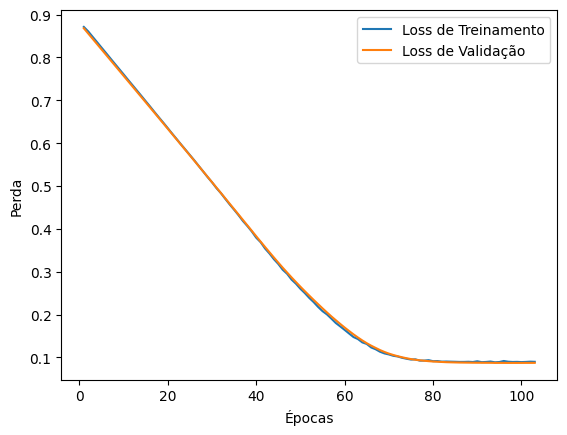

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step


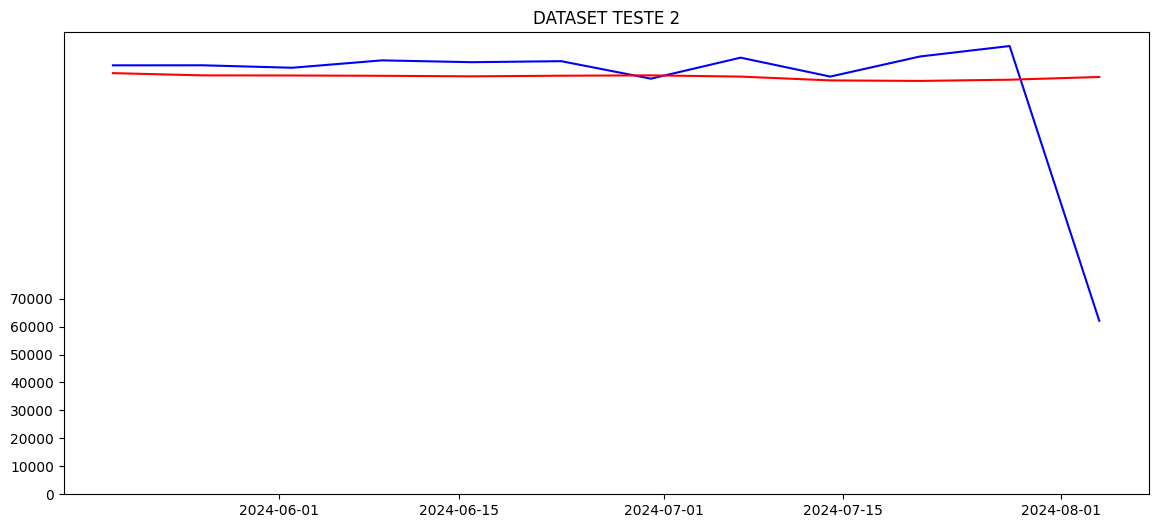

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.30000000000000004.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - loss: 0.8668 - val_loss: 0.8654
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.8562 - val_loss: 0.8532
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.8437 - val_loss: 0.8410
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.8313 - val_loss: 0.8288
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8189 - val_loss: 0.8166
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.8065 - val_loss: 0.8045
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.7941 - val_loss: 0.7923
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.7814 - val_loss: 0.7801
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.7690 - val_loss: 0.7679
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.7569 - val_loss: 0.7558
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.7441 - val_loss: 0.7436
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

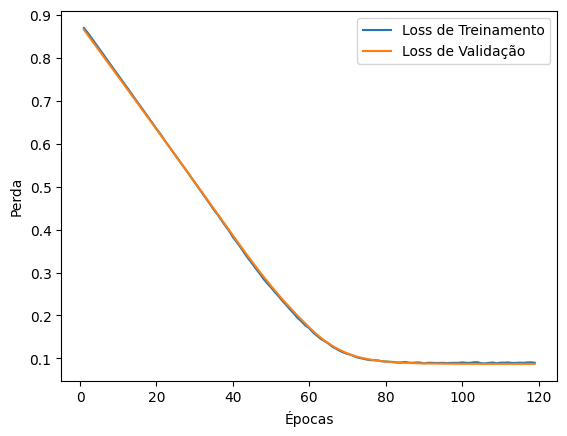

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


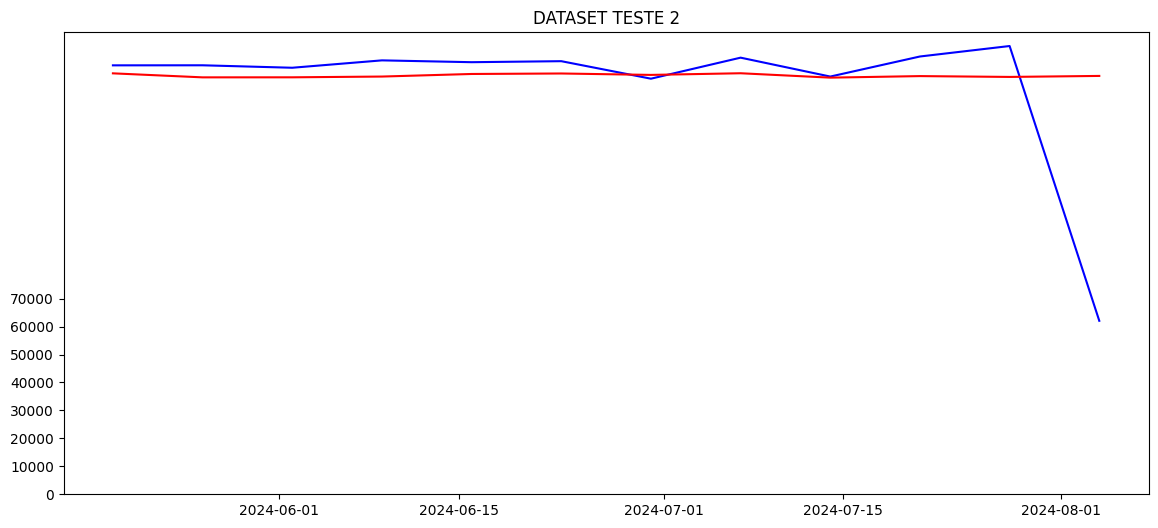

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.4.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - loss: 0.8679 - val_loss: 0.8694
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 332ms/step - loss: 0.8615 - val_loss: 0.8612
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.8533 - val_loss: 0.8530
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.8450 - val_loss: 0.8447
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.8368 - val_loss: 0.8365
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.8285 - val_loss: 0.8283
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.8203 - val_loss: 0.8201
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.8120 - val_loss: 0.8119
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.8038 - val_loss: 0.8037
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.7954 - val_loss: 0.7954
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.7872 - val_loss: 0.7872
Epoch 12/100000
2/2 ━━━━━━━━━━━━━

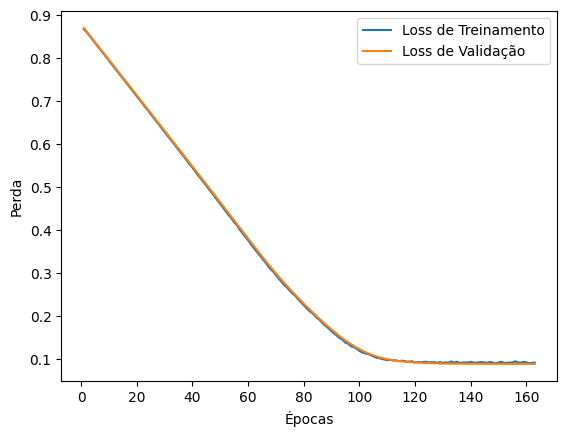

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


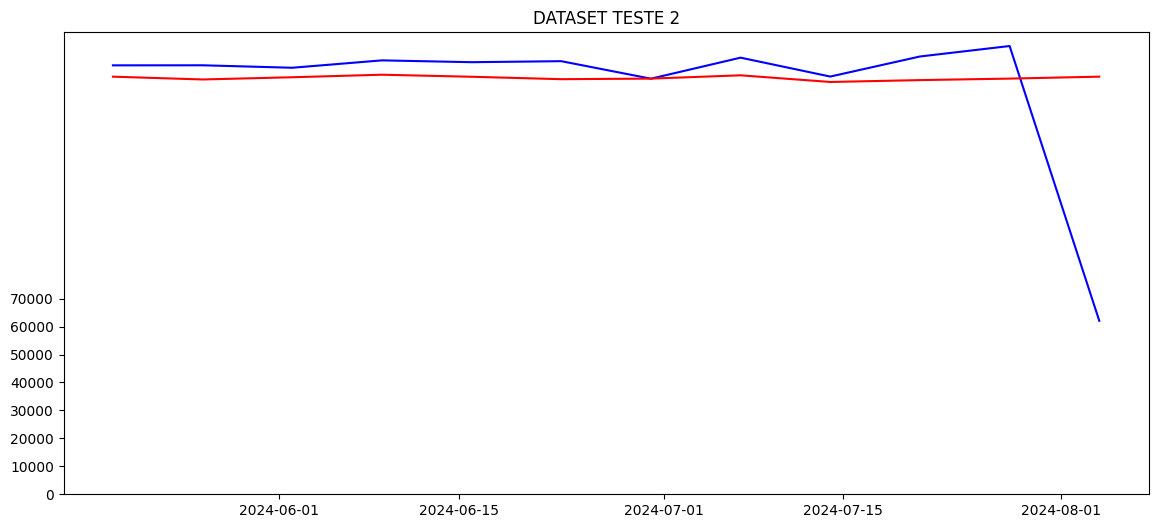

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.5.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - loss: 0.8695 - val_loss: 0.8655
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.8638 - val_loss: 0.8572
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.8555 - val_loss: 0.8487
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8470 - val_loss: 0.8401
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.8384 - val_loss: 0.8316
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.8298 - val_loss: 0.8230
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.8213 - val_loss: 0.8145
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.8126 - val_loss: 0.8059
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.8042 - val_loss: 0.7974
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.7959 - val_loss: 0.7889
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.7873 - val_loss: 0.7803
Epoch 12/100000
2/2 ━━━━━━━━━━━━━━━━━━━

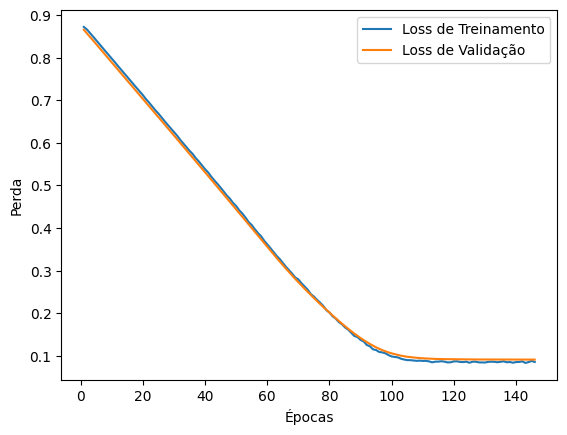

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


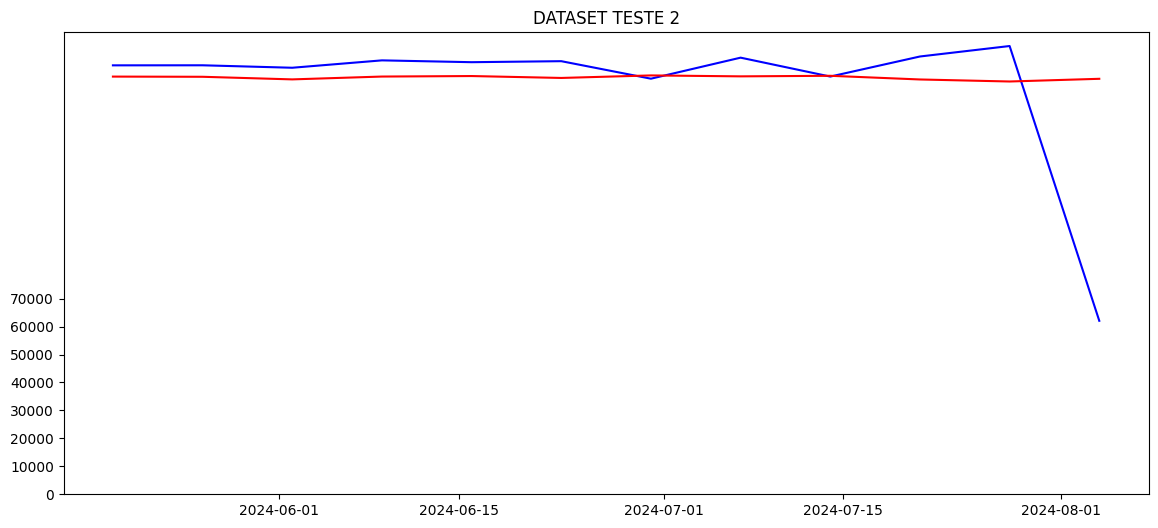

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.6.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 0.8680 - val_loss: 0.8699
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - loss: 0.8632 - val_loss: 0.8635
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.8567 - val_loss: 0.8558
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8489 - val_loss: 0.8478
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8409 - val_loss: 0.8398
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.8329 - val_loss: 0.8318
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8249 - val_loss: 0.8238
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.8169 - val_loss: 0.8158
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.8087 - val_loss: 0.8078
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.8007 - val_loss: 0.7998
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.7927 - val_loss: 0.7918
Epoch 12/100000
2/2 ━━━━━━━━━━━━━━━━━

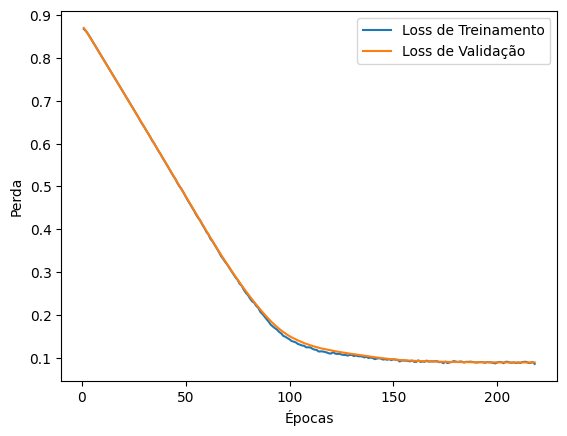

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


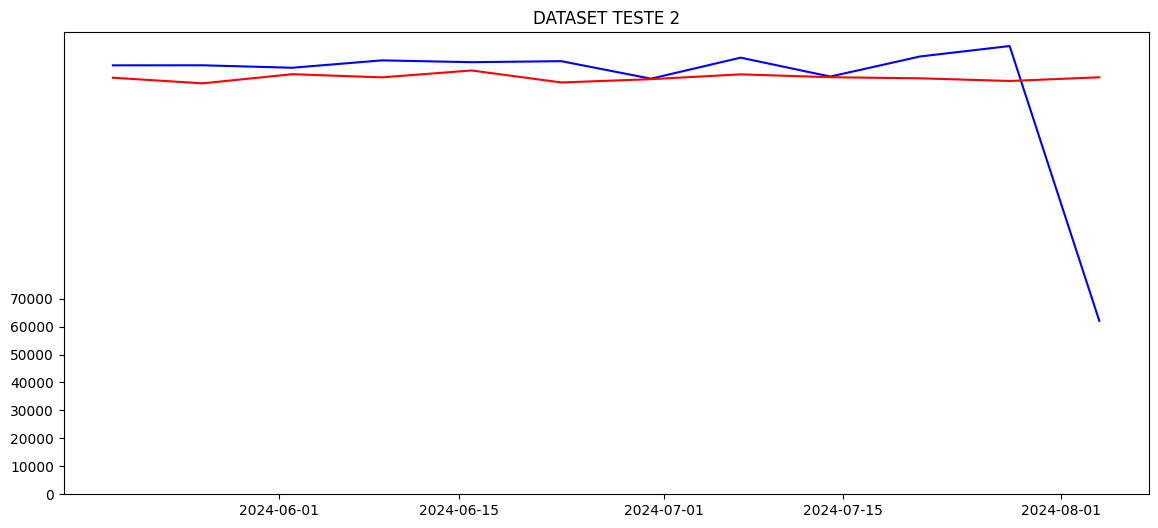

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.7.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - loss: 0.8639 - val_loss: 0.8730
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.8625 - val_loss: 0.8700
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.8596 - val_loss: 0.8666
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.8563 - val_loss: 0.8632
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.8529 - val_loss: 0.8595
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.8492 - val_loss: 0.8558
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.8455 - val_loss: 0.8520
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.8419 - val_loss: 0.8483
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 0.8381 - val_loss: 0.8446
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - loss: 0.8345 - val_loss: 0.8408
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - loss: 0.8310 - val_loss: 0.8371
Epoch 12/100000
1/1 ━━━━━━━━━━━

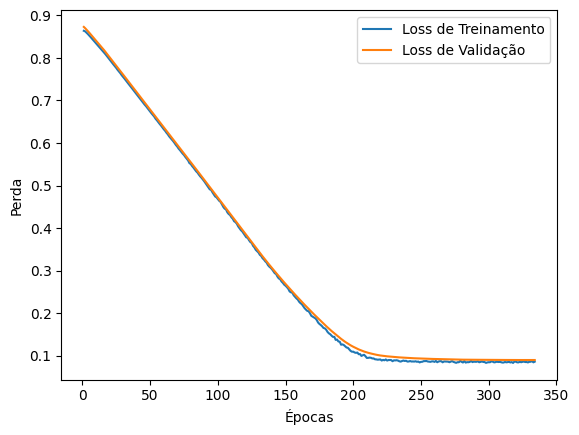

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


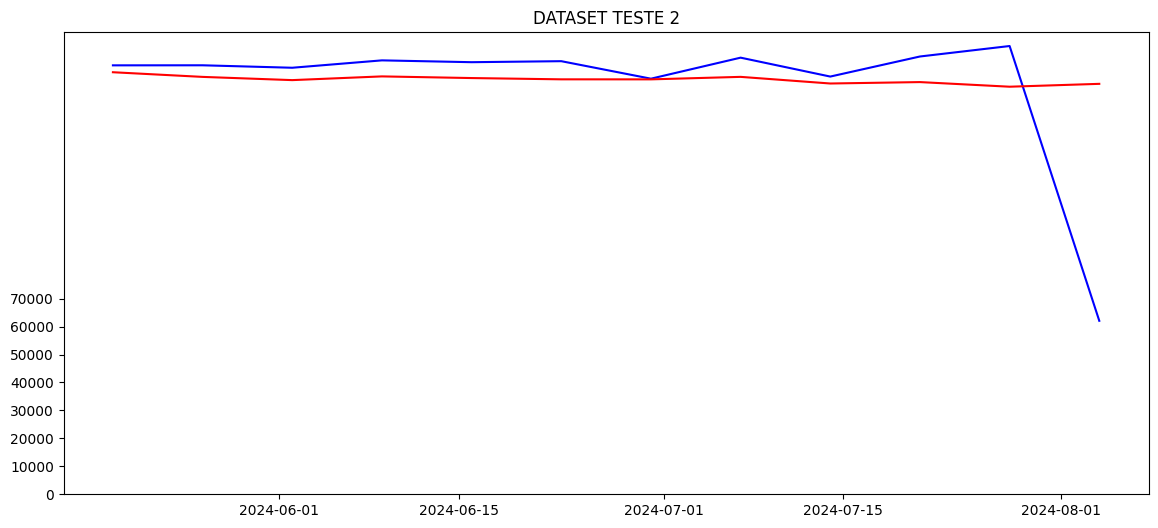

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.7999999999999999.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - loss: 0.8535 - val_loss: 0.8712
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.8519 - val_loss: 0.8682
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.8489 - val_loss: 0.8645
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - loss: 0.8453 - val_loss: 0.8606
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - loss: 0.8415 - val_loss: 0.8566
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - loss: 0.8376 - val_loss: 0.8527
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - loss: 0.8336 - val_loss: 0.8487
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.8297 - val_loss: 0.8447
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.8258 - val_loss: 0.8407
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.8220 - val_loss: 0.8367
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - loss: 0.8179 - val_loss: 0.8328
Epoch 12/100000
1/1 ━━━━━━━━━━━

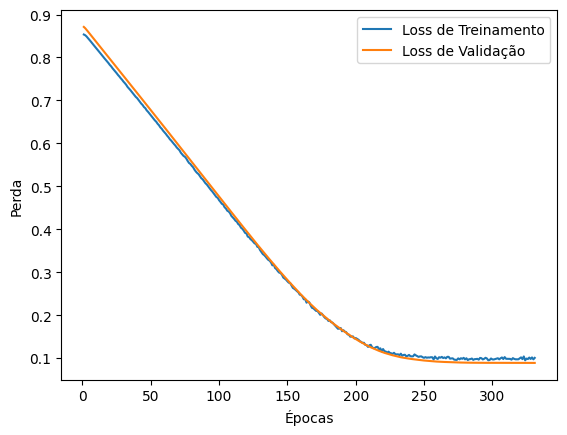

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


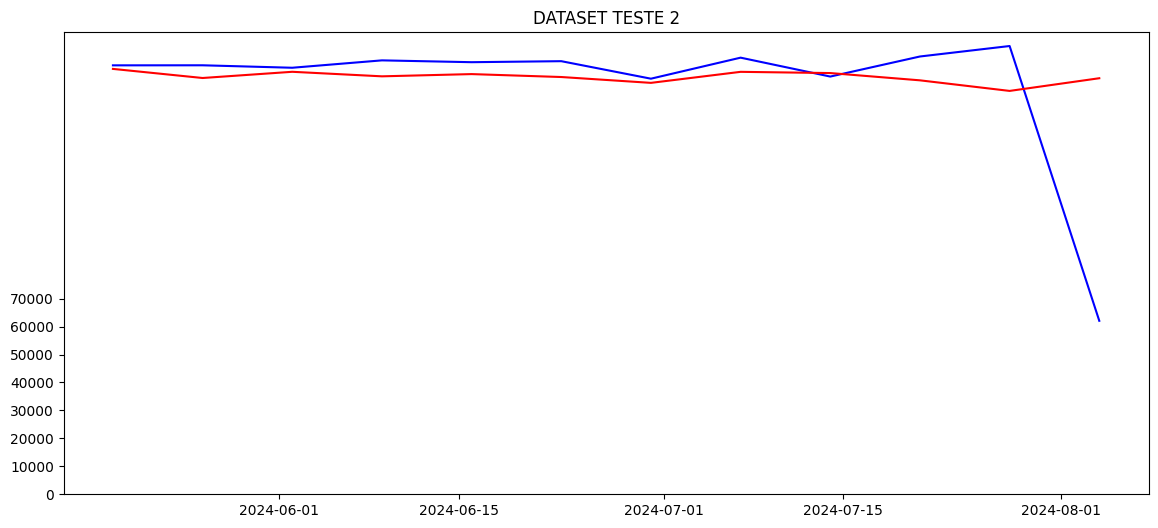

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.8999999999999999.txt


In [27]:
# for k in range(2,10):
#     model_2 = create_model(config, dataset_type_du, X, y, 'k-fold', k, 0)
#     results(model_2, duas_unas_validation_scaled, 'k-fold', diretorio_avaliacao_teste_2, k)

tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    model_2 = create_and_train_model(config, dataset_type_du, X, y, 'split', 0, tt_rate)
    results(model_2, duas_unas_validation_scaled, 'split', diretorio_avaliacao_teste_2, tt_rate)

## **TESTE 03**

Prata I, II, III, Pirapama e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Pirapama);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [24]:
### DATASETS PARA TESTE 03 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [0, 1, 2, 3]
dataset_test_3 = concatenate_selected_datasets(scaled_datasets, indices)

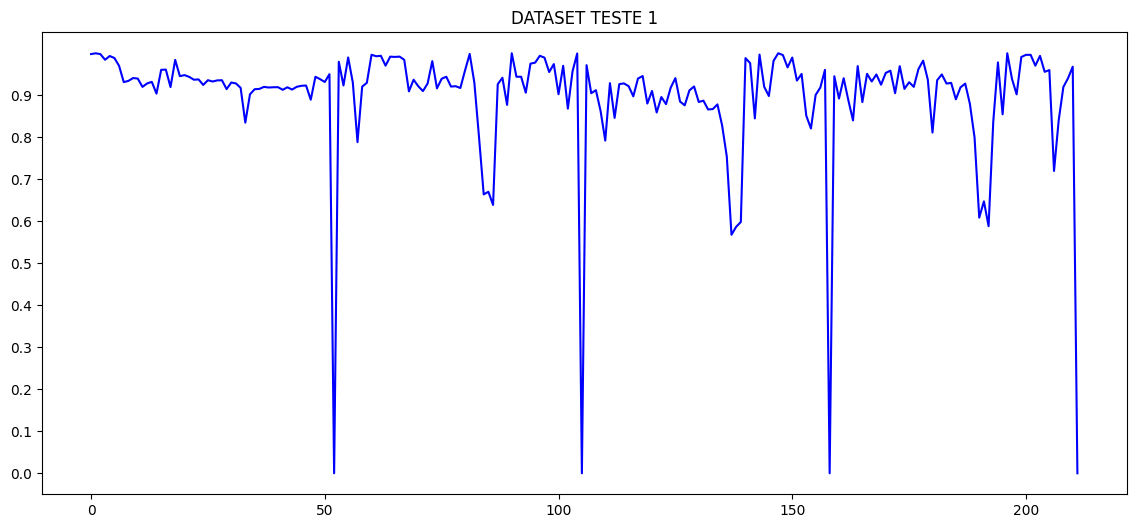

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_3, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_3, y_3 = create_dataset(dataset_test_3, timesteps, output_steps)
X_3 = X_3.reshape(X_3.shape[0], X_3.shape[1], 1)

#model3 = create_model(config, dataset_type_du, X_3, y_3, validation_method, 3)

X shape (200, 1)
y shape (200, 12)



Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 932ms/step - loss: 0.8927 - val_loss: 0.8718
Epoch 2/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8777 - val_loss: 0.8548
Epoch 3/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.8608 - val_loss: 0.8379
Epoch 4/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.8439 - val_loss: 0.8209
Epoch 5/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.8270 - val_loss: 0.8039
Epoch 6/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8101 - val_loss: 0.7869
Epoch 7/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.7934 - val_loss: 0.7700
Epoch 8/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7765 - val_loss: 0.7530
Epoch 9/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7597 - val_loss: 0.7360
Epoch 10/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7427 - val_loss: 0.7190
Epoch 11/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7258 - val_loss: 0.7020
Epoch 12/100000
4/4 ━━━━━━━━━━━━━━━━━━━━

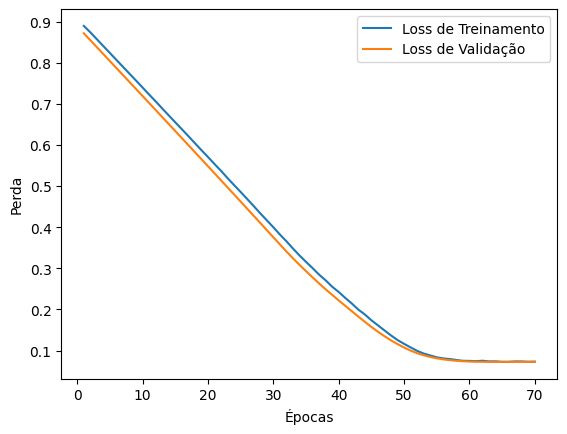

X shape (20, 1)
y shape (20, 12)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.8511 - val_loss: 0.8471
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step - loss: 0.8492 - val_loss: 0.8438
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 0.8458 - val_loss: 0.8397
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.8420 - val_loss: 0.8356
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8378 - val_loss: 0.8314
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.8330 - val_loss: 0.8271
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.8291 - val_loss: 0.8227
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.8242 - val_loss: 0.8182
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.8199 - val_loss: 0.8136
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.8149 - val_loss: 0.8091
Epoch 11/100000
1/1

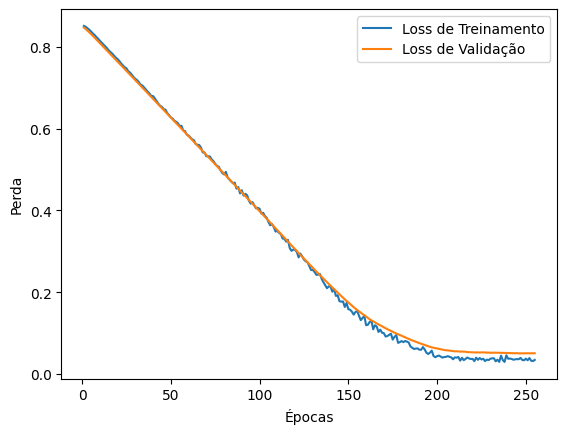

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


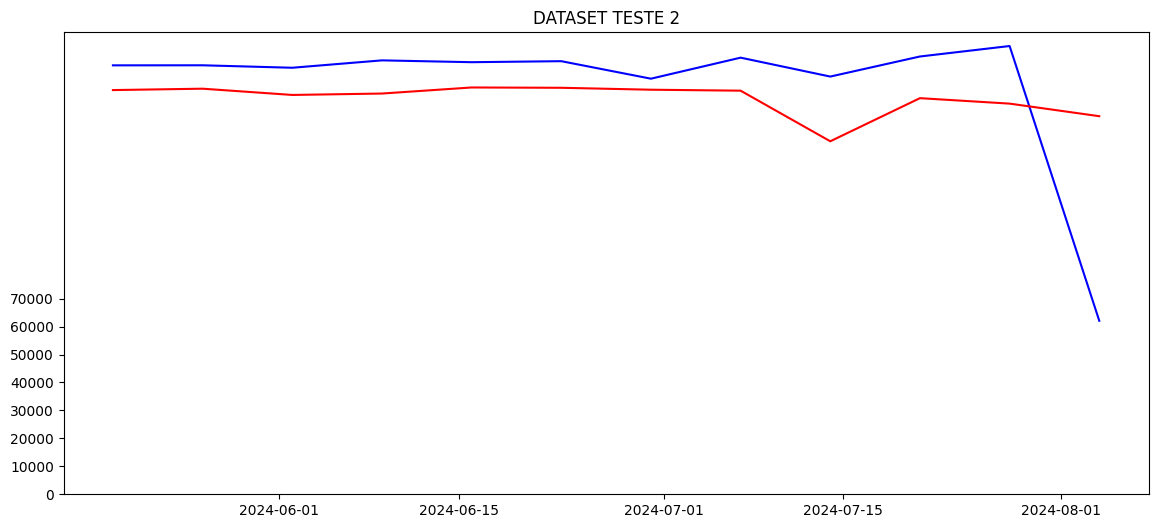

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.1.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 396ms/step - loss: 0.8924 - val_loss: 0.8712
Epoch 2/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8778 - val_loss: 0.8541
Epoch 3/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8607 - val_loss: 0.8371
Epoch 4/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8436 - val_loss: 0.8200
Epoch 5/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8266 - val_loss: 0.8029
Epoch 6/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8092 - val_loss: 0.7858
Epoch 7/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7925 - val_loss: 0.7687
Epoch 8/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7753 - val_loss: 0.7516
Epoch 9/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7582 - val_loss: 0.7345
Epoch 10/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7412 - val_loss: 0.7174
Epoch 11/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7241 - val_loss: 0.7003
Epoch 12/100000
4/4 ━━━━━━━━━━━━━━━━━━━━

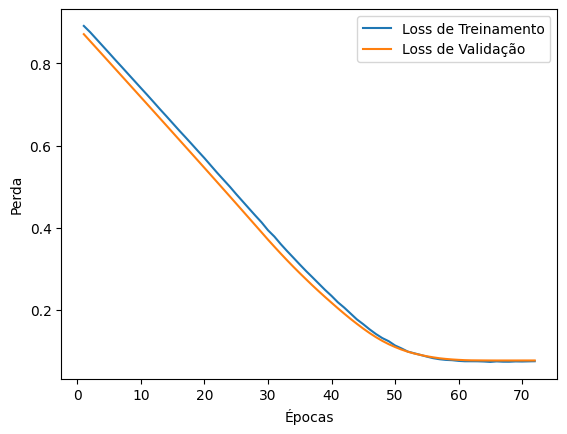

X shape (20, 1)
y shape (20, 12)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.8510 - val_loss: 0.8467
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.8487 - val_loss: 0.8432
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - loss: 0.8453 - val_loss: 0.8390
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.8412 - val_loss: 0.8345
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.8361 - val_loss: 0.8299
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.8312 - val_loss: 0.8253
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.8266 - val_loss: 0.8206
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.8222 - val_loss: 0.8160
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - loss: 0.8171 - val_loss: 0.8114
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.8135 - val_loss: 0.8069
Epoch 11/100000
1/1 ━━

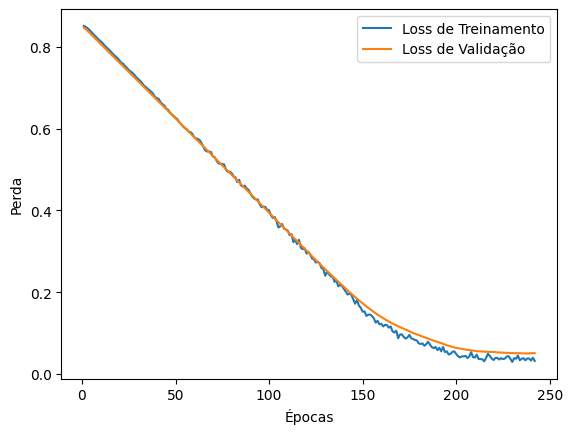

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


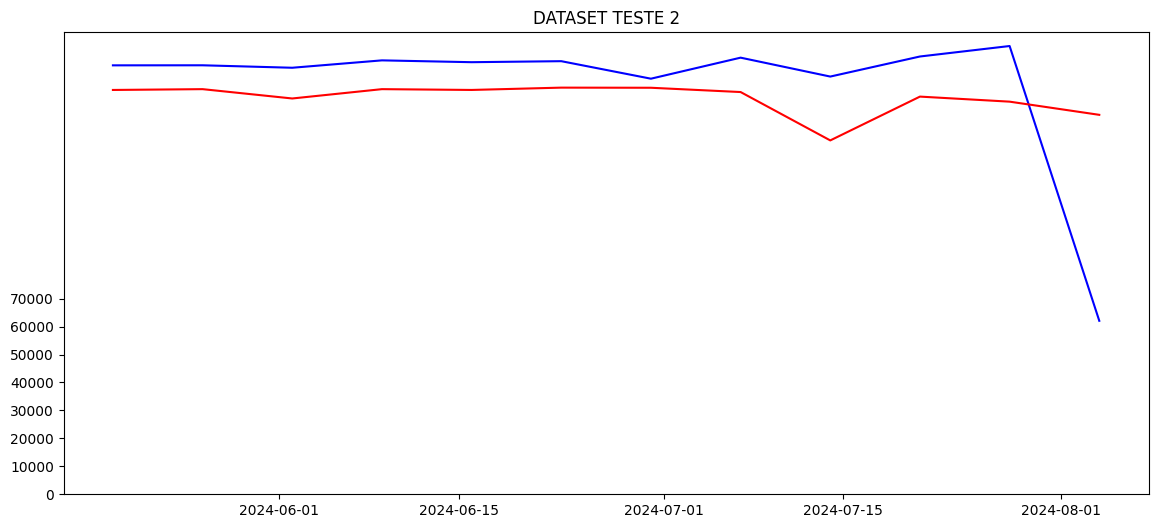

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.2.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 587ms/step - loss: 0.8935 - val_loss: 0.8795
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - loss: 0.8824 - val_loss: 0.8666
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.8696 - val_loss: 0.8537
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.8568 - val_loss: 0.8408
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.8441 - val_loss: 0.8280
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.8314 - val_loss: 0.8151
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8185 - val_loss: 0.8022
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8058 - val_loss: 0.7893
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.7928 - val_loss: 0.7764
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.7803 - val_loss: 0.7635
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.7674 - val_loss: 0.7506
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━

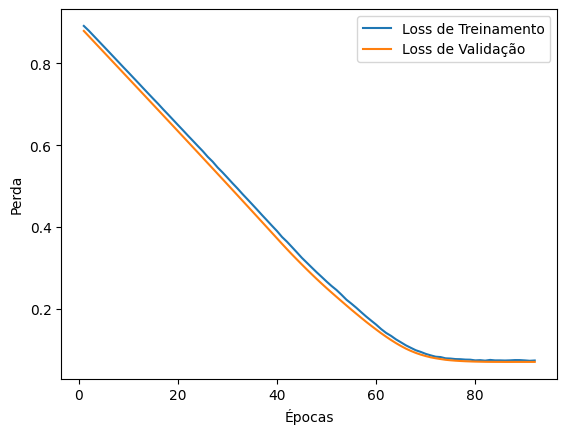

X shape (20, 1)
y shape (20, 12)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.8508 - val_loss: 0.8464
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8493 - val_loss: 0.8430
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.8452 - val_loss: 0.8387
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.8415 - val_loss: 0.8346
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.8368 - val_loss: 0.8301
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.8320 - val_loss: 0.8256
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.8280 - val_loss: 0.8210
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.8232 - val_loss: 0.8162
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.8184 - val_loss: 0.8116
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.8132 - val_loss: 0.8068
Epoch 11/100000
1/1

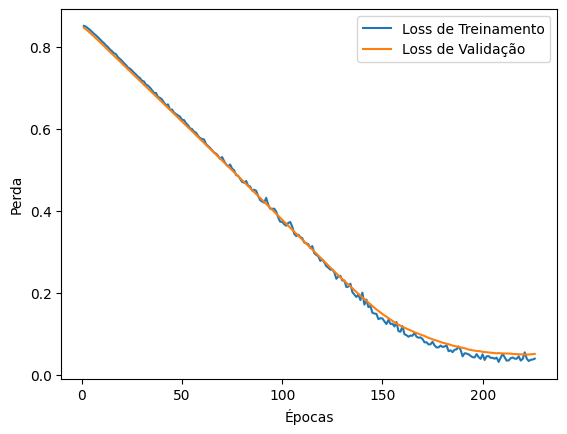

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step


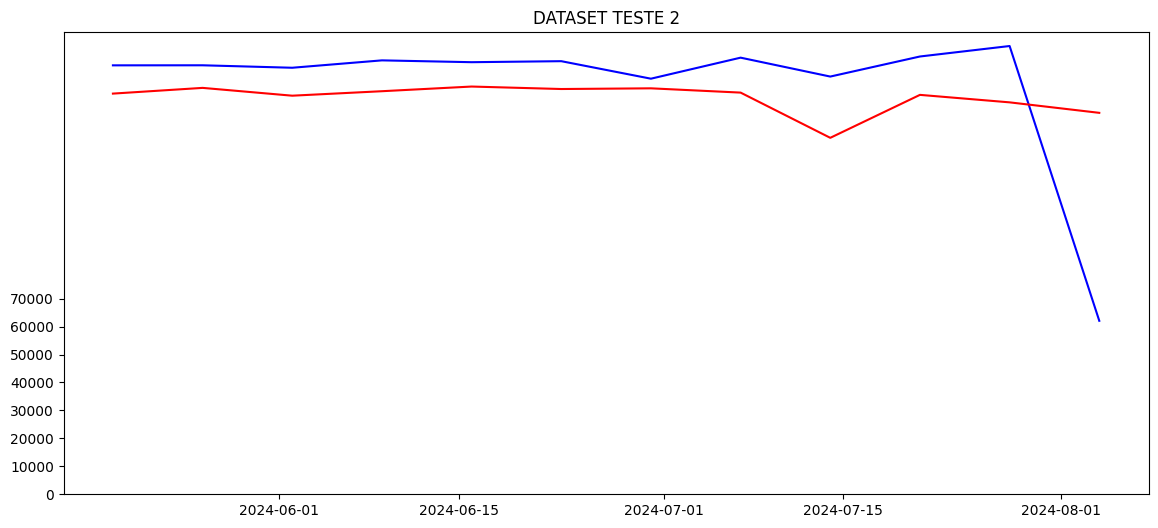

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.30000000000000004.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.8967 - val_loss: 0.8783
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8863 - val_loss: 0.8654
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.8735 - val_loss: 0.8526
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.8607 - val_loss: 0.8397
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.8478 - val_loss: 0.8268
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8349 - val_loss: 0.8140
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.8220 - val_loss: 0.8011
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.8090 - val_loss: 0.7882
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.7962 - val_loss: 0.7753
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.7833 - val_loss: 0.7624
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.7703 - val_loss: 0.7494
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s

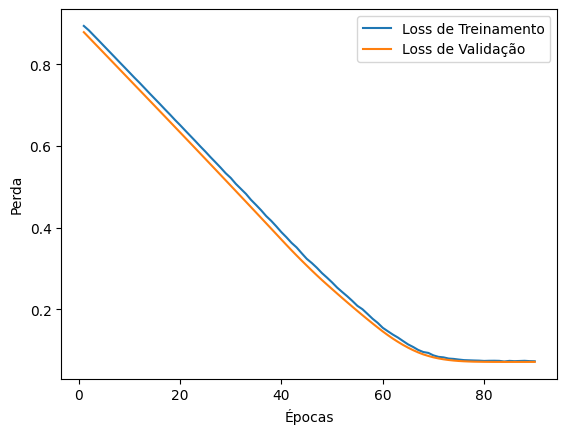

X shape (20, 1)
y shape (20, 12)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.8506 - val_loss: 0.8455
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.8480 - val_loss: 0.8414
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - loss: 0.8436 - val_loss: 0.8370
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.8395 - val_loss: 0.8324
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.8348 - val_loss: 0.8279
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.8300 - val_loss: 0.8233
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8252 - val_loss: 0.8187
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.8208 - val_loss: 0.8141
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.8155 - val_loss: 0.8095
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.8112 - val_loss: 0.8048
Epoch 11/100000
1/1 ━━

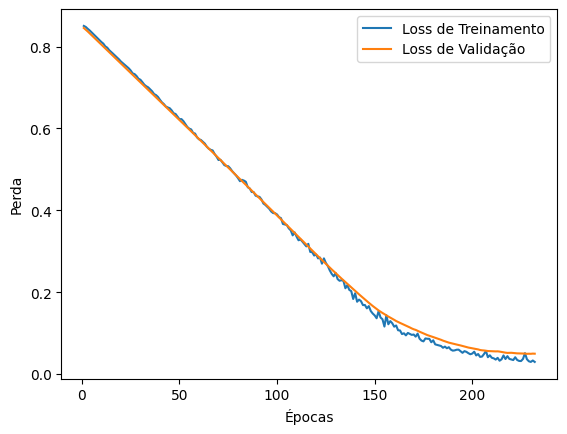

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


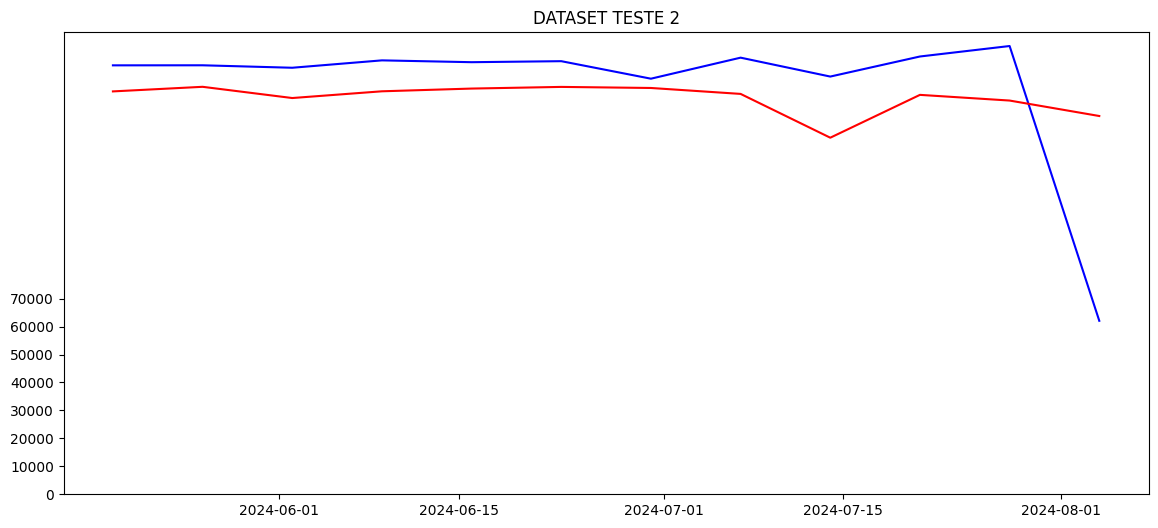

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.4.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 908ms/step - loss: 0.8895 - val_loss: 0.8807
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.8789 - val_loss: 0.8678
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8662 - val_loss: 0.8549
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.8534 - val_loss: 0.8420
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8406 - val_loss: 0.8291
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8278 - val_loss: 0.8162
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8152 - val_loss: 0.8033
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.8024 - val_loss: 0.7905
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.7898 - val_loss: 0.7776
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.7772 - val_loss: 0.7647
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.7642 - val_loss: 0.7517
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━

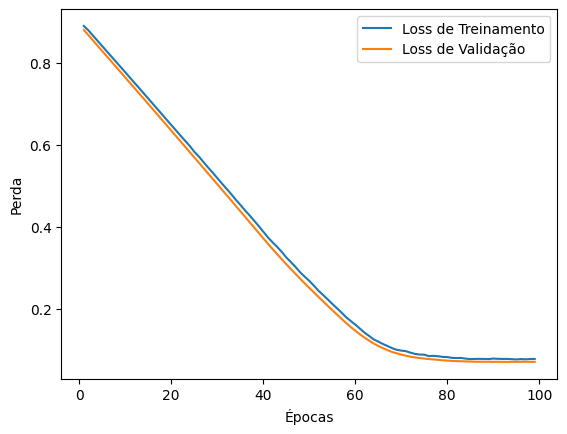

X shape (20, 1)
y shape (20, 12)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.8510 - val_loss: 0.8473
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.8496 - val_loss: 0.8440
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.8459 - val_loss: 0.8399
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.8428 - val_loss: 0.8359
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.8384 - val_loss: 0.8319
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.8338 - val_loss: 0.8278
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.8298 - val_loss: 0.8235
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8255 - val_loss: 0.8192
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.8208 - val_loss: 0.8146
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.8163 - val_loss: 0.8100
Epoch 11/100000
1/1

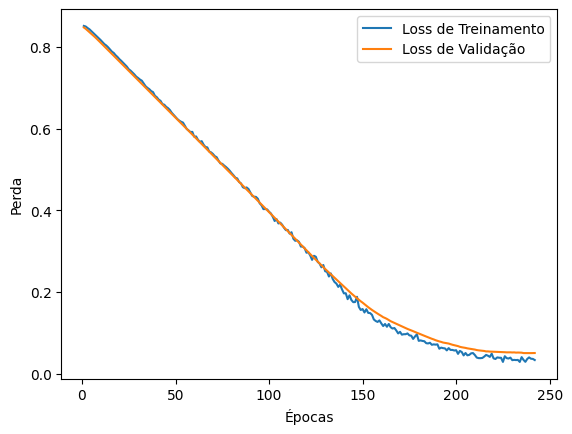

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step


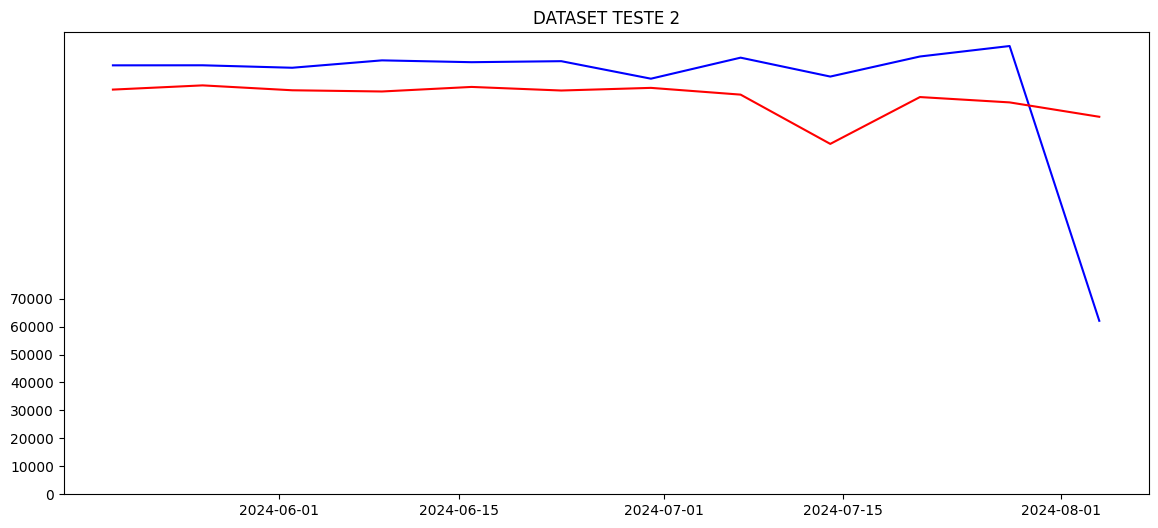

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.5.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.8837 - val_loss: 0.8889
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.8775 - val_loss: 0.8802
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.8688 - val_loss: 0.8714
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8601 - val_loss: 0.8627
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8516 - val_loss: 0.8539
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8430 - val_loss: 0.8452
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.8343 - val_loss: 0.8364
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.8259 - val_loss: 0.8277
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8169 - val_loss: 0.8189
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.8082 - val_loss: 0.8102
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.7997 - val_loss: 0.8014
Epoch 12/100000
2/2 ━━━━━━━━━━━━━━━━━━━━

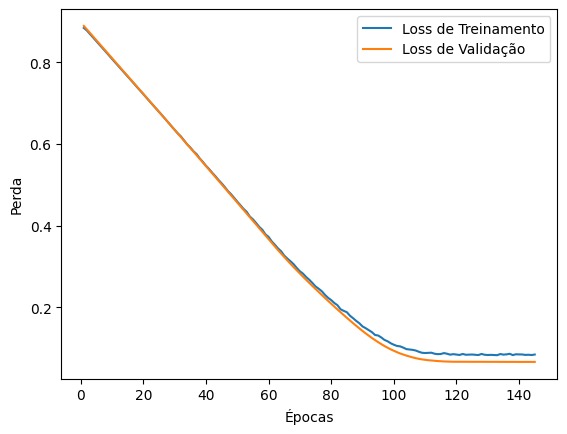

X shape (20, 1)
y shape (20, 12)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.8506 - val_loss: 0.8462
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.8483 - val_loss: 0.8434
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.8454 - val_loss: 0.8399
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - loss: 0.8420 - val_loss: 0.8364
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - loss: 0.8378 - val_loss: 0.8323
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.8334 - val_loss: 0.8281
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.8296 - val_loss: 0.8239
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.8255 - val_loss: 0.8197
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.8208 - val_loss: 0.8155
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.8169 - val_loss: 0.8114
Epoch 11/100000
1/1 ━━

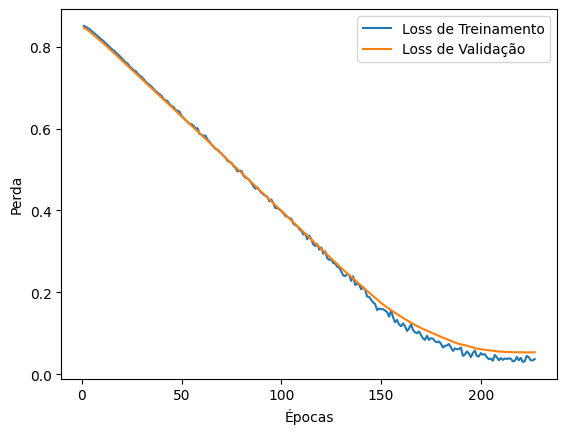

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step


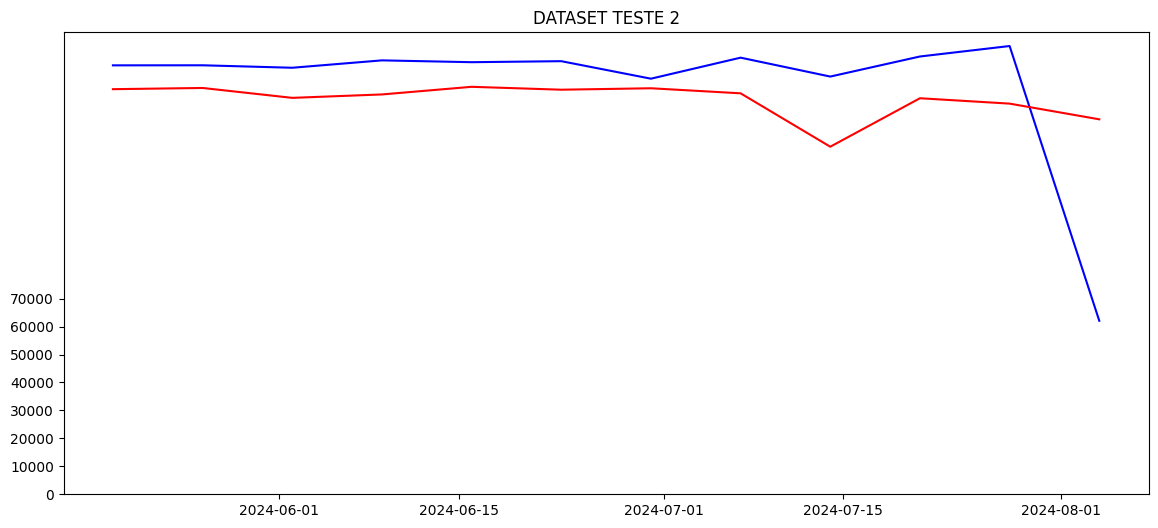

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.6.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - loss: 0.8927 - val_loss: 0.8864
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - loss: 0.8872 - val_loss: 0.8787
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 0.8794 - val_loss: 0.8709
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.8714 - val_loss: 0.8631
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8634 - val_loss: 0.8547
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.8549 - val_loss: 0.8463
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.8464 - val_loss: 0.8378
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8378 - val_loss: 0.8293
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.8293 - val_loss: 0.8209
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8206 - val_loss: 0.8124
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.8122 - val_loss: 0.8040
Epoch 12/100000
2/2 ━━━━━━━━━━━━━━━━

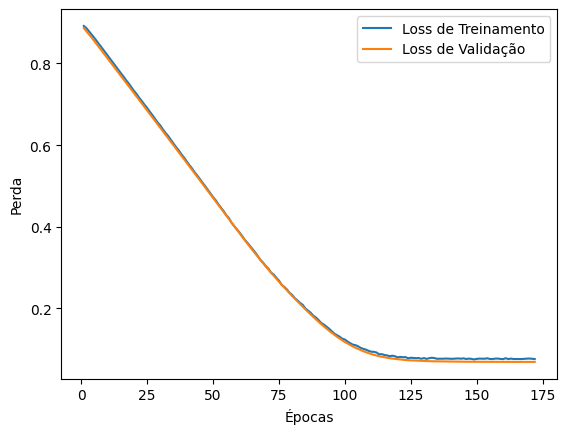

X shape (20, 1)
y shape (20, 12)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step - loss: 0.8510 - val_loss: 0.8466
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - loss: 0.8485 - val_loss: 0.8429
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - loss: 0.8452 - val_loss: 0.8392
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.8412 - val_loss: 0.8356
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - loss: 0.8379 - val_loss: 0.8318
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - loss: 0.8341 - val_loss: 0.8277
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 0.8297 - val_loss: 0.8233
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 0.8250 - val_loss: 0.8189
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.8207 - val_loss: 0.8145
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.8165 - val_loss: 0.8100
Epoch 11/100000
1/1 ━━━

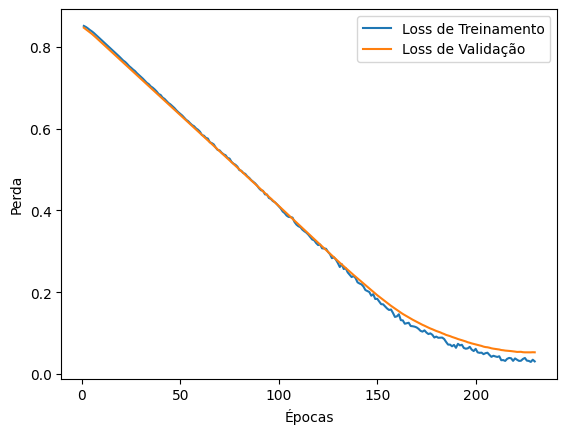

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


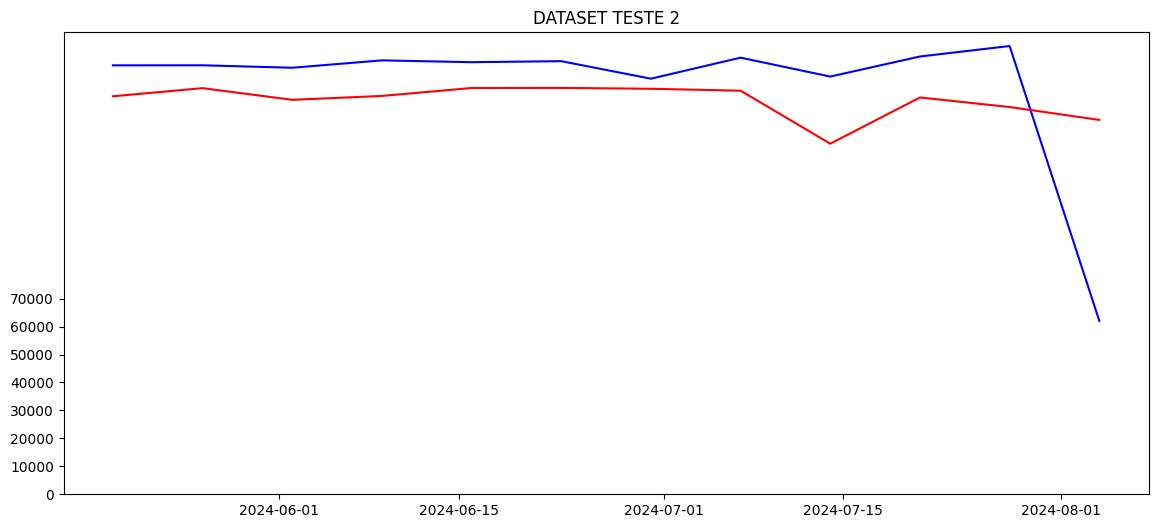

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.7.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - loss: 0.8961 - val_loss: 0.8901
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.8943 - val_loss: 0.8865
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.8908 - val_loss: 0.8823
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.8866 - val_loss: 0.8781
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.8824 - val_loss: 0.8738
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.8781 - val_loss: 0.8696
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.8739 - val_loss: 0.8653
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - loss: 0.8696 - val_loss: 0.8611
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - loss: 0.8654 - val_loss: 0.8569
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.8611 - val_loss: 0.8526
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.8569 - val_loss: 0.8484
Epoch 12/100000
1/1 ━━━━━━━━━━━

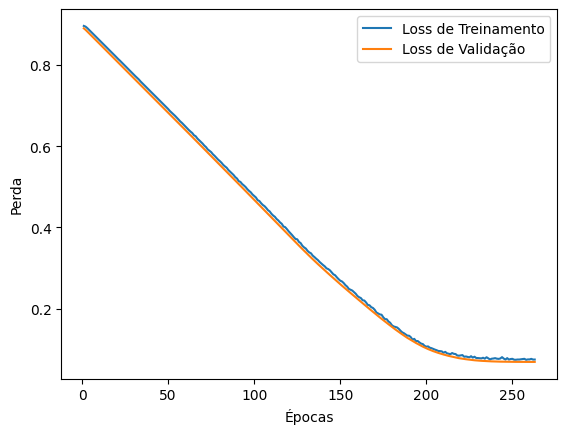

X shape (20, 1)
y shape (20, 12)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_45 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_46 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - loss: 0.8507 - val_loss: 0.8468
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - loss: 0.8490 - val_loss: 0.8440
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.8462 - val_loss: 0.8403
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.8425 - val_loss: 0.8366
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.8384 - val_loss: 0.8328
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 0.8348 - val_loss: 0.8287
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - loss: 0.8301 - val_loss: 0.8245
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - loss: 0.8264 - val_loss: 0.8204
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss: 0.8216 - val_loss: 0.8162
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - loss: 0.8178 - val_loss: 0.8121
Epoch 11/100000
1/1 ━━━

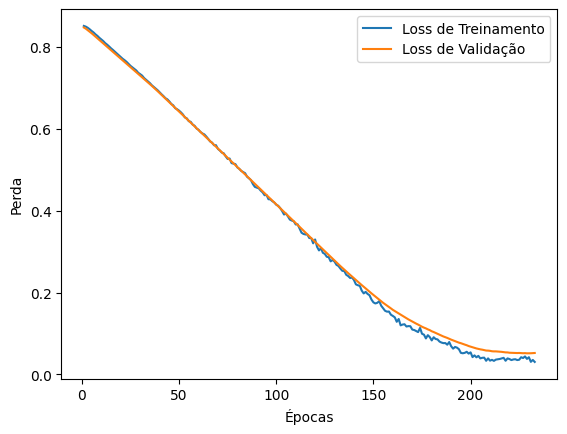

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


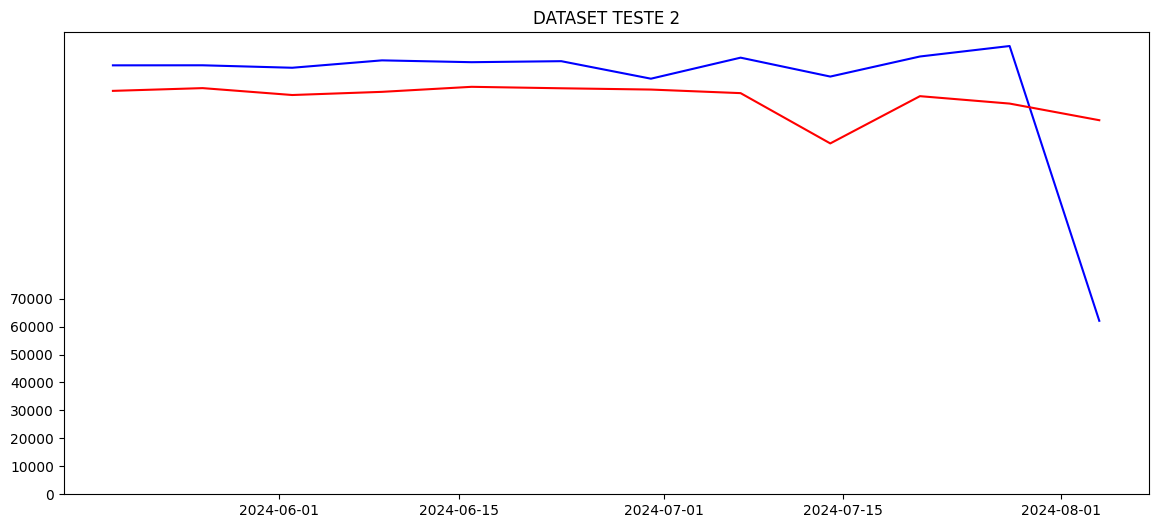

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.7999999999999999.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step - loss: 0.8775 - val_loss: 0.8914
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.8760 - val_loss: 0.8886
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step - loss: 0.8733 - val_loss: 0.8851
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step - loss: 0.8699 - val_loss: 0.8813
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.8661 - val_loss: 0.8772
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.8620 - val_loss: 0.8730
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.8580 - val_loss: 0.8689
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - loss: 0.8540 - val_loss: 0.8648
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step - loss: 0.8499 - val_loss: 0.8606
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.8458 - val_loss: 0.8565
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - loss: 0.8418 - val_loss: 0.8524
Epoch 12/100000
1/1 ━━━━━━━━━━━━━━

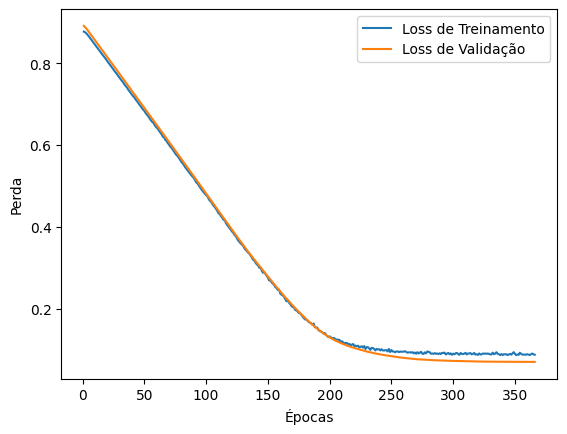

X shape (20, 1)
y shape (20, 12)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_51 (LSTM)                  │ (None, 1, 42)          │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 1, 42)          │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 1, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 42)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 12)             │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,468 (142.45 KB)

 Trainable params: 36,468 (142.45 KB)

 Non-trainable params: 0 (0.00 B)

(1, 168)
(42, 168)
(168,)
(42, 168)
(42, 168)
(168,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - loss: 0.8509 - val_loss: 0.8468
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - loss: 0.8490 - val_loss: 0.8435
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.8457 - val_loss: 0.8399
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 0.8421 - val_loss: 0.8361
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - loss: 0.8379 - val_loss: 0.8322
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 0.8340 - val_loss: 0.8283
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.8292 - val_loss: 0.8242
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.8251 - val_loss: 0.8198
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.8206 - val_loss: 0.8151
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - loss: 0.8167 - val_loss: 0.8105
Epoch 11/100000
1

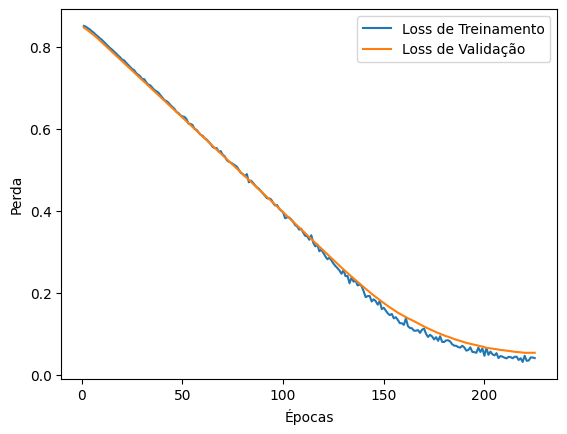

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


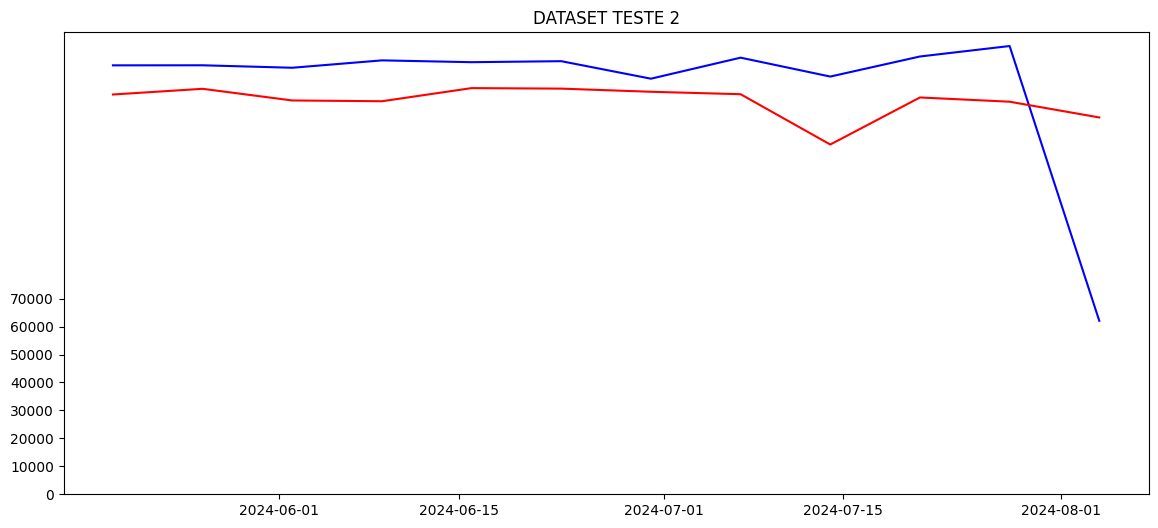

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.8999999999999999.txt


In [27]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model3 = train_model(X_3, y_3, validation_method, k, tt_rate=0)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3, 'teste_3', validation_method, str(k))
    
# Treinamento com train-test split
tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    print("\nTraining with train-test split")
    validation_method = 'split'
    model3 = create_and_train_model(config, dataset_type_du, X_3, y_3, validation_method, None, tt_rate)
    transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3,'teste_3', validation_method, tt_rate)

In [28]:
# # Salvamento dos pesos após primeiro treinamento

# pesos_treinamento3 = model3.get_weights()
# pesos_LSTM1_t3 = model3.layers[0].get_weights()
# pesos_LSTM2_t3 = model3.layers[2].get_weights()
# pesos_LSTM3_t3 = model3.layers[4].get_weights()
# pesos_DENSE_t3 = model3.layers[6].get_weights()

# # Salvar pesos de cada camada LSTM em arquivos .npz
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'), *pesos_LSTM1_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'), *pesos_LSTM2_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'), *pesos_LSTM3_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_DENSE_t3_{validation_method}.npz'), *pesos_DENSE_t3)

# # Para salvar os pesos do modelo completo
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_modelo_t3_{validation_method}.npz'), *pesos_treinamento3)

In [29]:
# # Carregar pesos do arquivo .npz
# pesos_carregados_LSTM1_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'))
# pesos_carregados_LSTM2_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'))
# pesos_carregados_LSTM3_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'))

In [30]:
# X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
# X = X.reshape(X.shape[0], X.shape[1], 1)

# model3_ft = Sequential()

# for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
#     model3_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os bias
#                     return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

#     model3_ft.add(Dropout(0.3))

# model3_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os biases
#                     activation=config['datasets'][dataset_type_du]['activation']))

# model3_ft.summary()

In [31]:
# # Caminho dos pesos salvos
# caminho_LSTM1_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz')
# caminho_LSTM2_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz')
# caminho_LSTM3_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz')

# carregar_e_aplicar_pesos(model3_ft, caminho_LSTM1_t3, caminho_LSTM2_t3, caminho_LSTM3_t3)

In [32]:
# # Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

# ### CAMADA LSTM 1
# sao_iguais1 = np.array_equal(pesos_LSTM1_t3[0], model3_ft.layers[0].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM1_t3[1], model3_ft.layers[0].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM1_t3[2], model3_ft.layers[0].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 2
# sao_iguais1 = np.array_equal(pesos_LSTM2_t3[0], model3_ft.layers[2].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM2_t3[1], model3_ft.layers[2].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM2_t3[2], model3_ft.layers[2].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# # ### CAMADA LSTM 3
# # sao_iguais1 = np.array_equal(pesos_LSTM3_t3[0], model3_ft.layers[4].get_weights()[0])
# # sao_iguais2 = np.array_equal(pesos_LSTM3_t3[1], model3_ft.layers[4].get_weights()[1])
# # sao_iguais3 = np.array_equal(pesos_LSTM3_t3[2], model3_ft.layers[4].get_weights()[2])

# # print(sao_iguais1)
# # print(sao_iguais2)
# # print(sao_iguais3)

In [33]:
# congelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.005

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [34]:
# descongelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.0008

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [35]:
# pred = model3_ft.predict(duas_unas_validation_scaled.iloc[0])
# y_pred_rescaled = scalers[4].inverse_transform(pred)
# y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
# duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

# plt.figure(figsize=(14,6))
# plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
# plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
# plt.yticks(np.arange(0,80000,step=10000))
# plt.title("DATASET TESTE 3")

# # Nome do arquivo incluindo a variável 'validation_method'
# file_name = f'prediction_plot_with_method_{validation_method}.png'

# # Caminho completo para salvar o arquivo
# save_path = os.path.join(diretorio_avaliacao_teste_3, file_name)

# # Salvar o plot
# plt.savefig(save_path)
# plt.show()

In [36]:
# avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

# # Nome do arquivo incluindo a variável 'validation_method'
# output_file = f'avaliacao_with_method_{validation_method}.txt'

# save_function_output(avaliacao_multistep, 
#                      duas_unas_validation_rescaled, 
#                      y_pred_rescaled, 
#                      output_file = output_file, 
#                      output_dir=diretorio_avaliacao_teste_3)

## **Teste 04**

Prata I, II, III, Pirapama e Duas Unas. Ações a serem testadas:

1. Padronizar cada dataset em separado (Prata I, II, III, Pirapama e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [24]:
### DATASETS PARA TESTE 04 ###

indices = [0, 1, 2, 3, 4]
dataset_test_4 = concatenate_selected_datasets(scaled_datasets, indices)

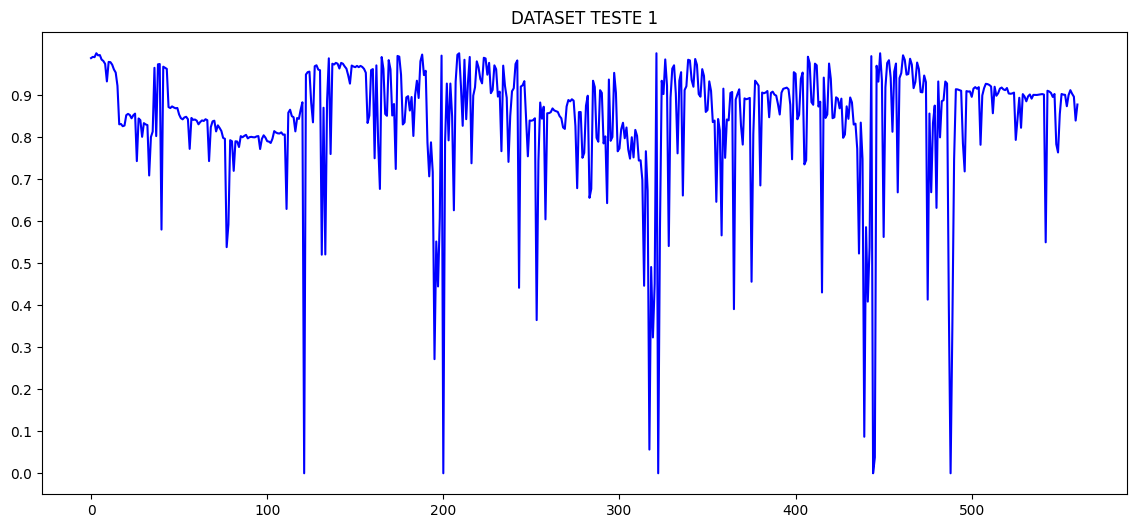

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_4, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (531, 1)
y shape (531, 30)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.7294 - val_loss: 0.1364
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1924 - val_loss: 0.1462
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1824 - val_loss: 0.0940
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1682 - val_loss: 0.0934
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1625 - val_loss: 0.0929
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1531 - val_loss: 0.0919
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1511 - val_loss: 0.0922
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1468 - val_loss: 0.0920
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1414 - val_loss: 0.0924
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1447 - val_loss: 0.0983
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1414 - val_loss: 0.0959
Epoch 12/100000
1

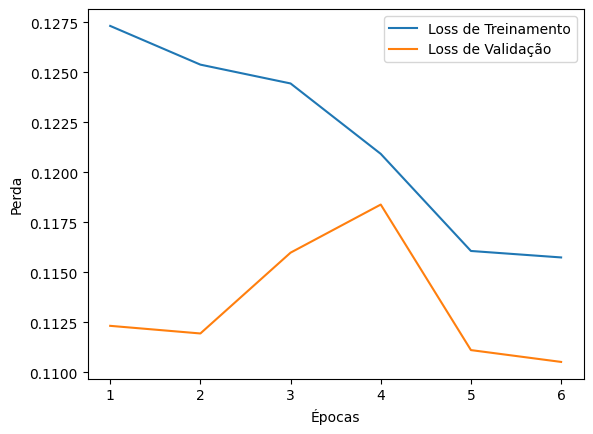

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step


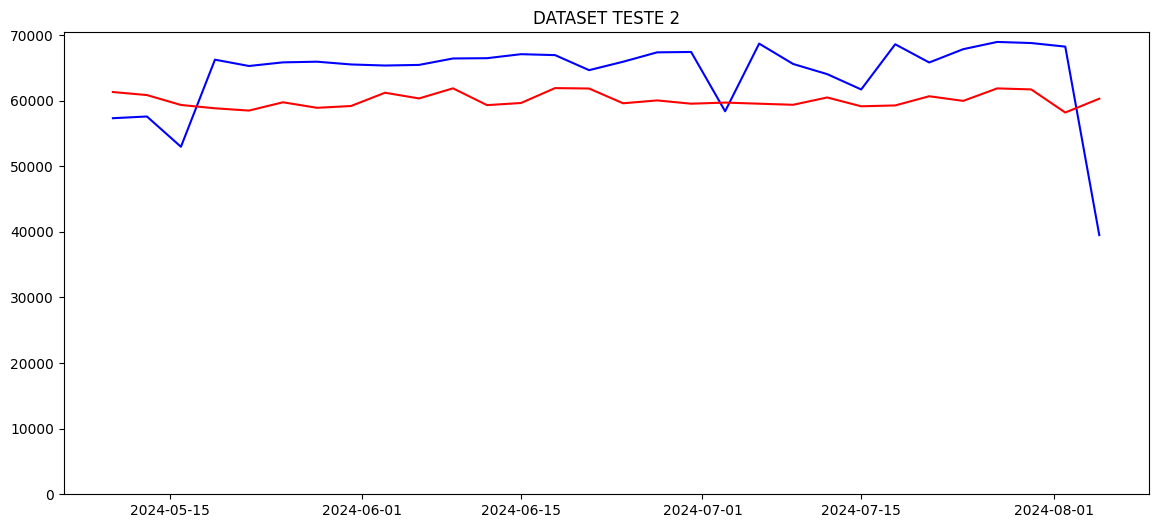

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_2.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.6814 - val_loss: 0.0890
Epoch 2/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1812 - val_loss: 0.1191
Epoch 3/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1672 - val_loss: 0.0836
Epoch 4/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1544 - val_loss: 0.0936
Epoch 5/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1529 - val_loss: 0.0843
Epoch 6/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1513 - val_loss: 0.0856
Epoch 7/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1437 - val_loss: 0.0842
Epoch 8/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1381 - val_loss: 0.0939
Epoch 9/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1430 - val_loss: 0.1020
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1505 - val_loss: 0.1325
Epoch 2/100000
24/24 ━━━━━━━━━━━━━

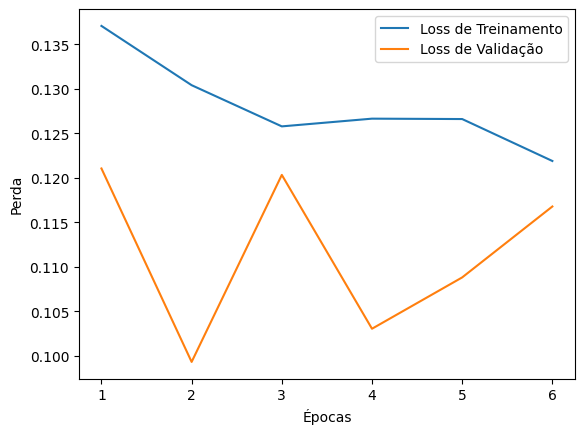

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step


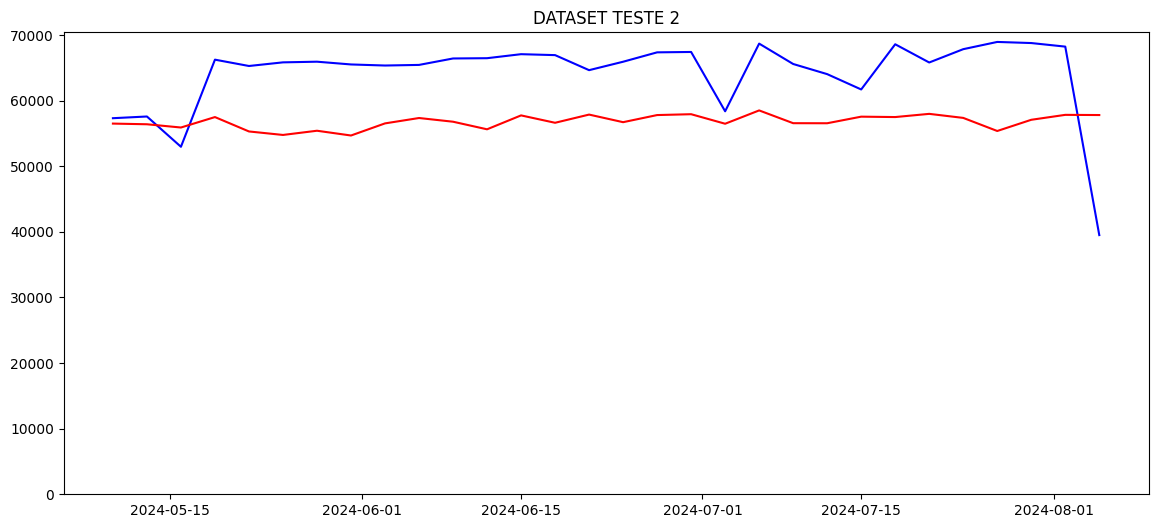

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_3.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.6540 - val_loss: 0.1035
Epoch 2/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1789 - val_loss: 0.0952
Epoch 3/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1687 - val_loss: 0.0882
Epoch 4/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1514 - val_loss: 0.0782
Epoch 5/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1439 - val_loss: 0.0757
Epoch 6/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1447 - val_loss: 0.0828
Epoch 7/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1416 - val_loss: 0.0807
Epoch 8/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1362 - val_loss: 0.0770
Epoch 9/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1346 - val_loss: 0.1143
Epoch 10/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1282 - val_loss: 0.0738
Epoch 11/100000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1276 - val_loss: 0.0954
Epoch 12/100000
27/27 ━━━━━

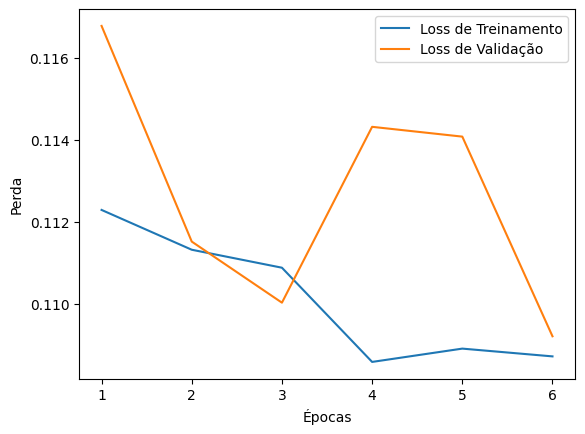

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step


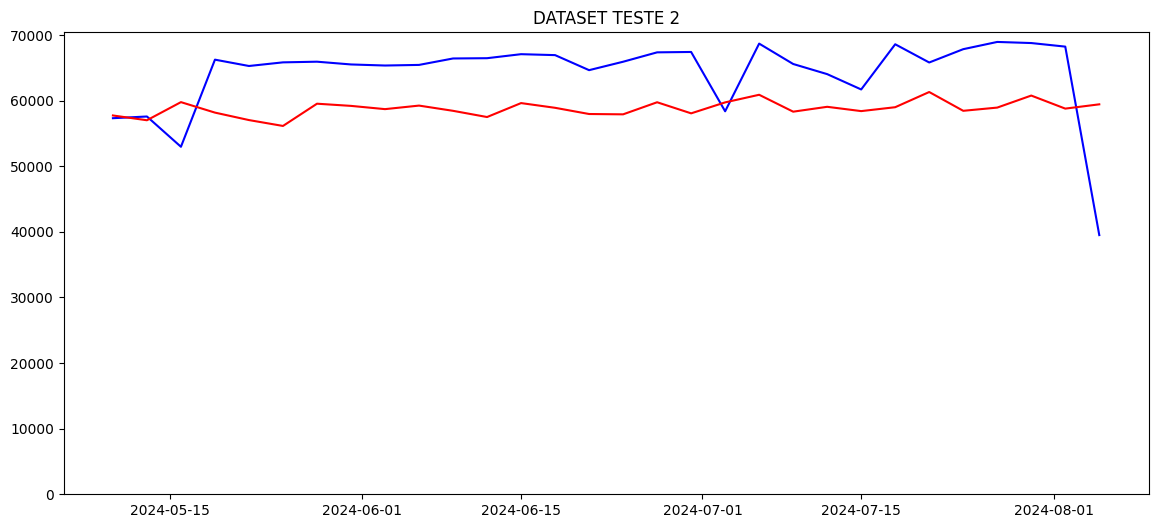

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_4.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.6649 - val_loss: 0.0897
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1813 - val_loss: 0.0663
Epoch 3/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1628 - val_loss: 0.1887
Epoch 4/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1583 - val_loss: 0.1779
Epoch 5/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1546 - val_loss: 0.0848
Epoch 6/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1437 - val_loss: 0.0671
Epoch 7/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1341 - val_loss: 0.1160
Epoch 8/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1320 - val_loss: 0.1053
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 2.
Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1528 - val_loss: 0.1226
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1392 - val_loss: 0.1167
Epoch 3/100000
29/29 ━━━━━━━━━━━━

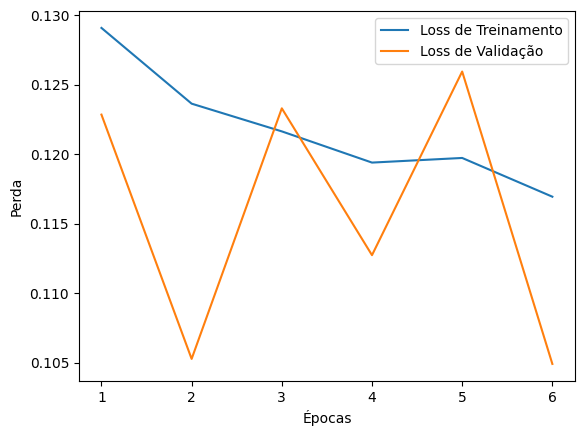

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step


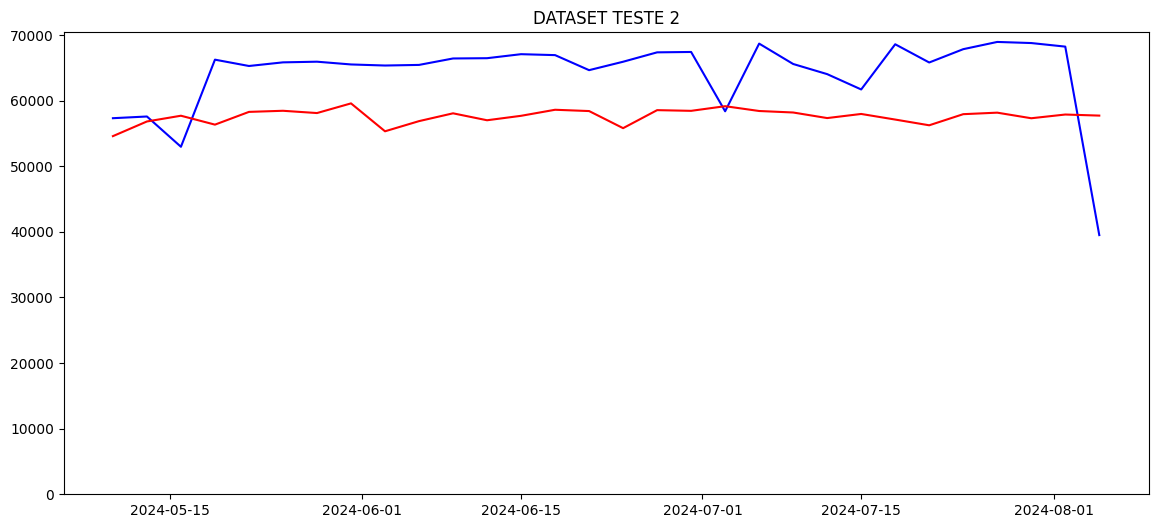

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_5.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.6380 - val_loss: 0.0546
Epoch 2/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1714 - val_loss: 0.0671
Epoch 3/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1590 - val_loss: 0.0630
Epoch 4/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1485 - val_loss: 0.0560
Epoch 5/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1459 - val_loss: 0.0530
Epoch 6/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1407 - val_loss: 0.0707
Epoch 7/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1300 - val_loss: 0.0529
Epoch 8/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1330 - val_loss: 0.0929
Epoch 9/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1336 - val_loss: 0.0733
Epoch 10/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1264 - val_loss: 0.0740
Epoch 11/100000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1267 - val_loss: 0.0712
Epoch 12/100000
30/30 ━━━━━

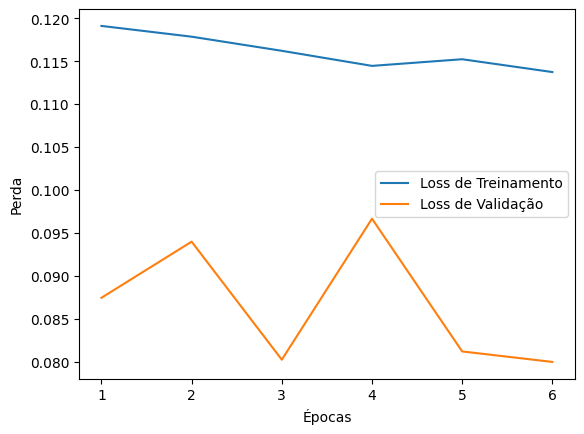

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step


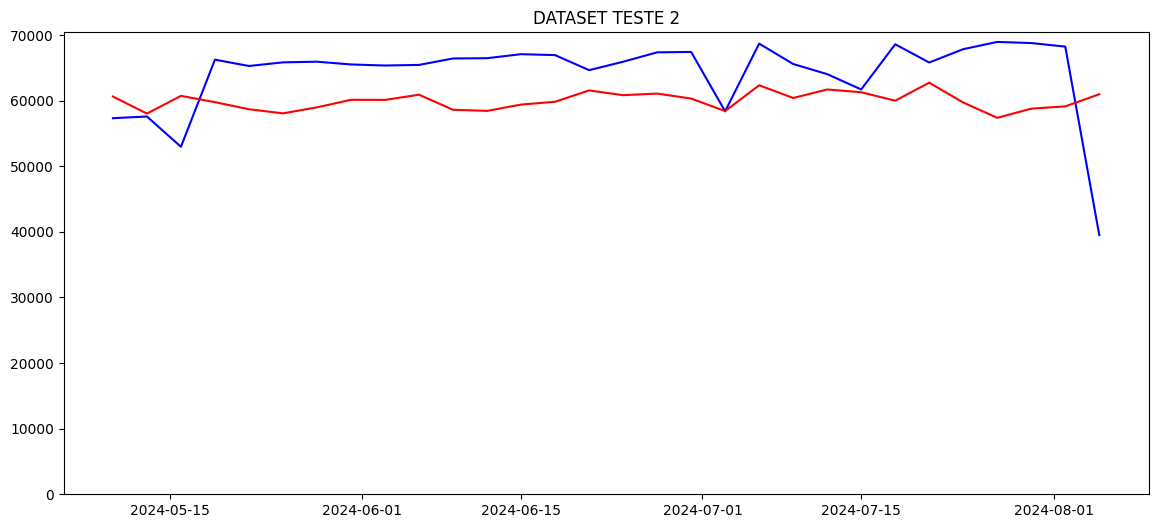

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_6.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.6347 - val_loss: 0.1710
Epoch 2/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1806 - val_loss: 0.0607
Epoch 3/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1640 - val_loss: 0.0903
Epoch 4/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1530 - val_loss: 0.0806
Epoch 5/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1425 - val_loss: 0.0694
Epoch 6/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1360 - val_loss: 0.0897
Epoch 7/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1343 - val_loss: 0.0781
Epoch 8/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1350 - val_loss: 0.0958
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 2.
Epoch 1/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1573 - val_loss: 0.1017
Epoch 2/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1455 - val_loss: 0.1080
Epoch 3/100000
31/31 ━━━━━━━━━━━━

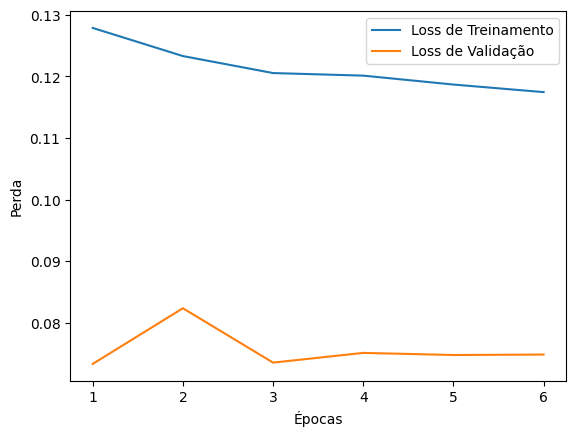

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step


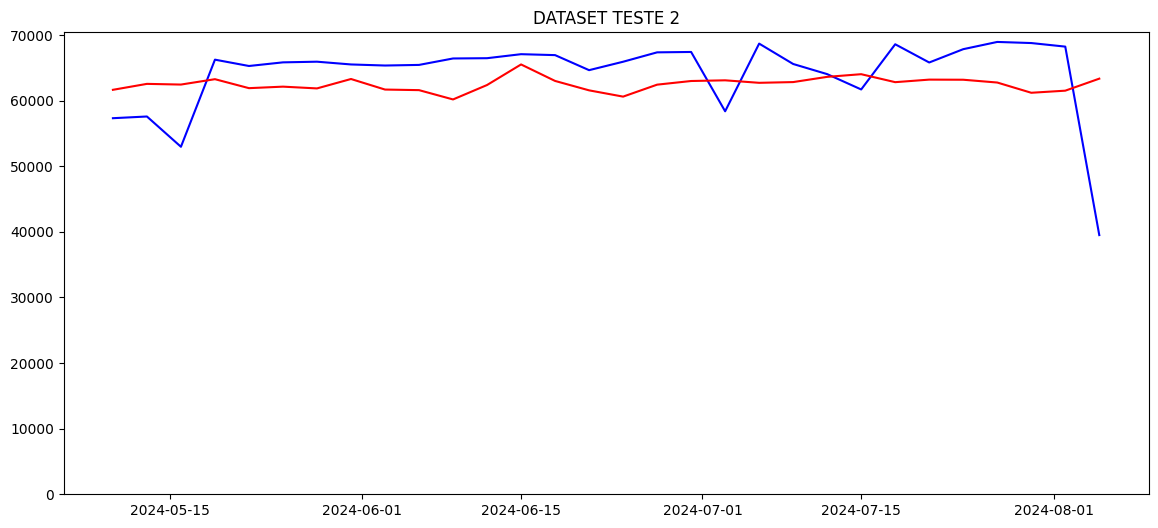

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_7.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.6178 - val_loss: 0.0629
Epoch 2/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1727 - val_loss: 0.0585
Epoch 3/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1605 - val_loss: 0.0658
Epoch 4/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1467 - val_loss: 0.0599
Epoch 5/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1448 - val_loss: 0.0646
Epoch 6/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1359 - val_loss: 0.0670
Epoch 7/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1393 - val_loss: 0.0843
Epoch 8/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1343 - val_loss: 0.0576
Epoch 9/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1267 - val_loss: 0.0663
Epoch 10/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1280 - val_loss: 0.0601
Epoch 11/100000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1252 - val_loss: 0.0595
Epoch 12/100000
31/31 ━━━━━

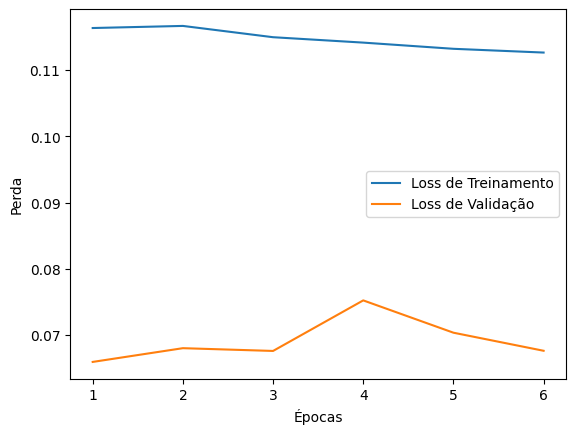

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step


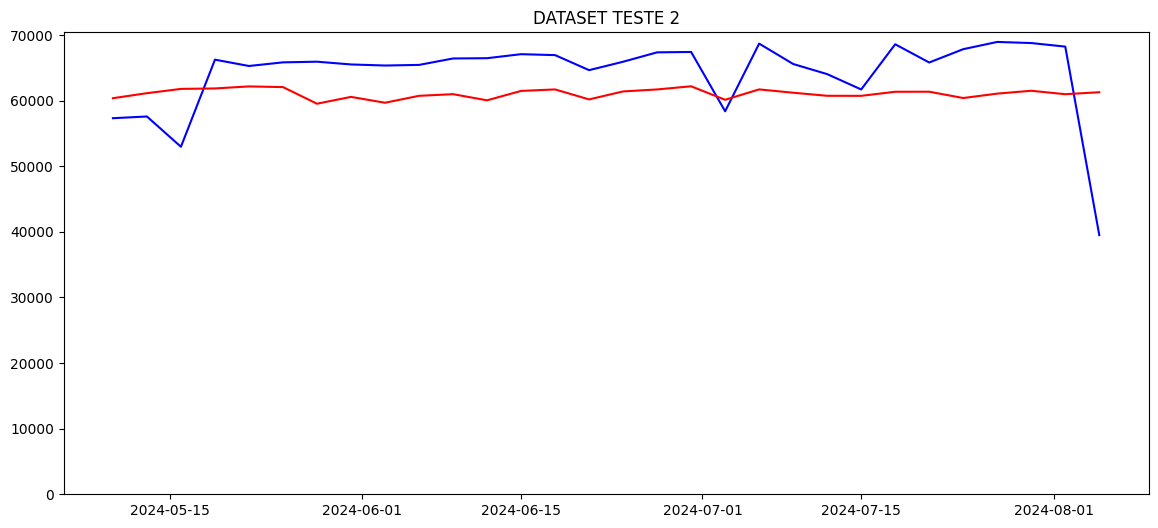

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_8.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.6238 - val_loss: 0.1016
Epoch 2/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1750 - val_loss: 0.0645
Epoch 3/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1568 - val_loss: 0.0580
Epoch 4/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1416 - val_loss: 0.0800
Epoch 5/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1397 - val_loss: 0.0639
Epoch 6/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1326 - val_loss: 0.0581
Epoch 7/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1268 - val_loss: 0.0631
Epoch 8/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1270 - val_loss: 0.0569
Epoch 9/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1244 - val_loss: 0.0615
Epoch 10/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1204 - val_loss: 0.0649
Epoch 11/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1193 - val_loss: 0.0801
Epoch 12/100000
32/32 ━━━

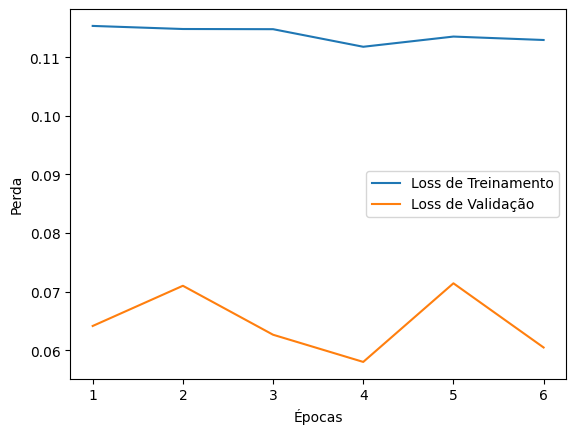

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step


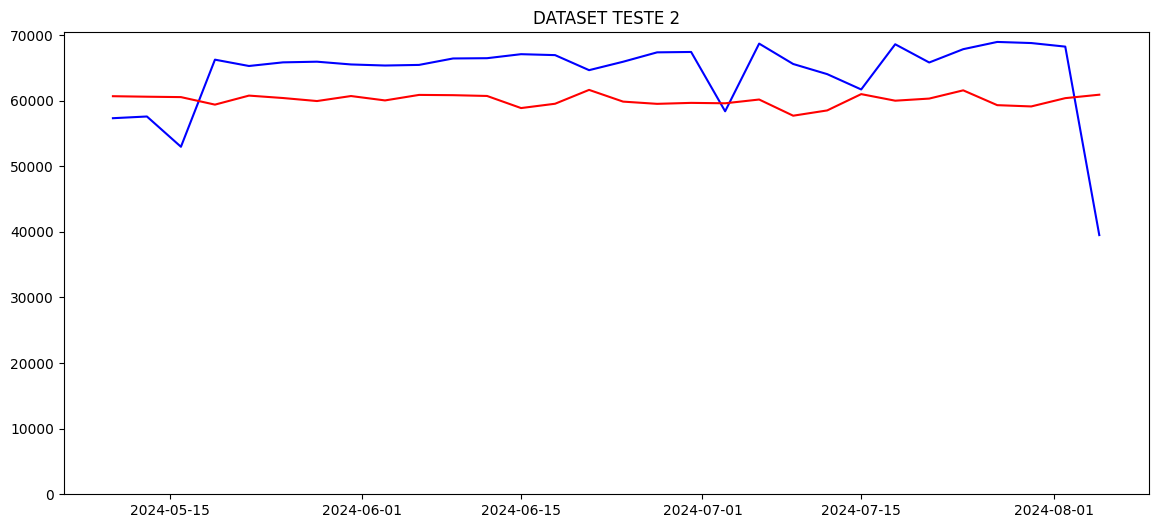

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_9.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.6100 - val_loss: 0.1115
Epoch 2/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1598 - val_loss: 0.1300
Epoch 3/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1522 - val_loss: 0.1069
Epoch 4/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1375 - val_loss: 0.1046
Epoch 5/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1269 - val_loss: 0.1097
Epoch 6/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1242 - val_loss: 0.1041
Epoch 7/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1228 - val_loss: 0.1043
Epoch 8/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1186 - val_loss: 0.1032
Epoch 9/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1176 - val_loss: 0.1035
Epoch 10/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1158 - val_loss: 0.1016
Epoch 11/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1165 - val_loss: 0.1021
Epoch 12/100000
32/32 ━━━━━━

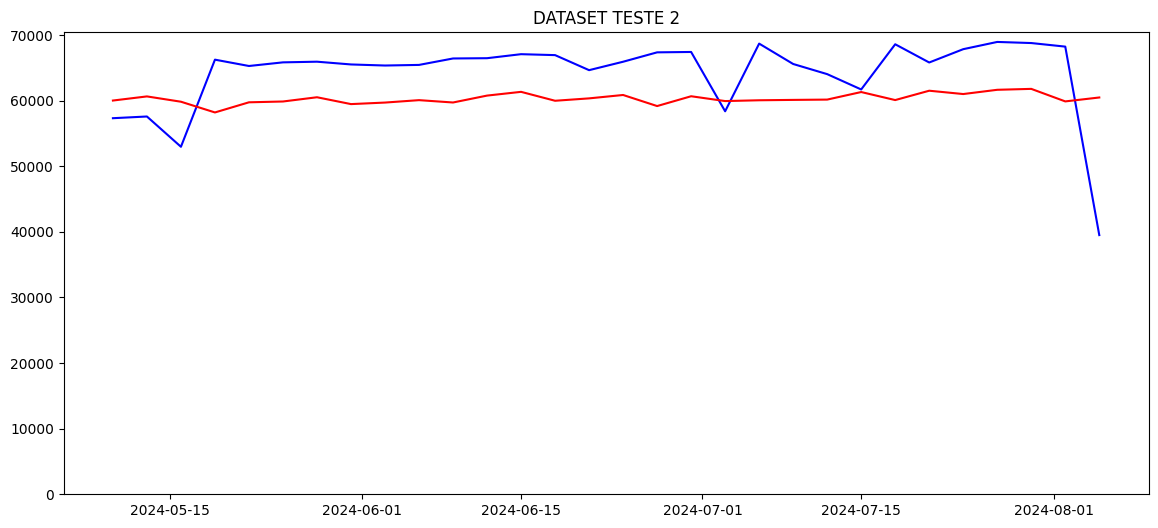

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.1.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.6447 - val_loss: 0.1599
Epoch 2/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1633 - val_loss: 0.1085
Epoch 3/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1482 - val_loss: 0.1158
Epoch 4/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1376 - val_loss: 0.1044
Epoch 5/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1290 - val_loss: 0.1040
Epoch 6/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1296 - val_loss: 0.1024
Epoch 7/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1226 - val_loss: 0.1054
Epoch 8/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1237 - val_loss: 0.1067
Epoch 9/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1198 - val_loss: 0.1100
Epoch 10/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1193 - val_loss: 0.1033
Epoch 11/100000
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1160 - val_loss: 0.1039
Epoch 12/100000
29/29 ━━━━━━

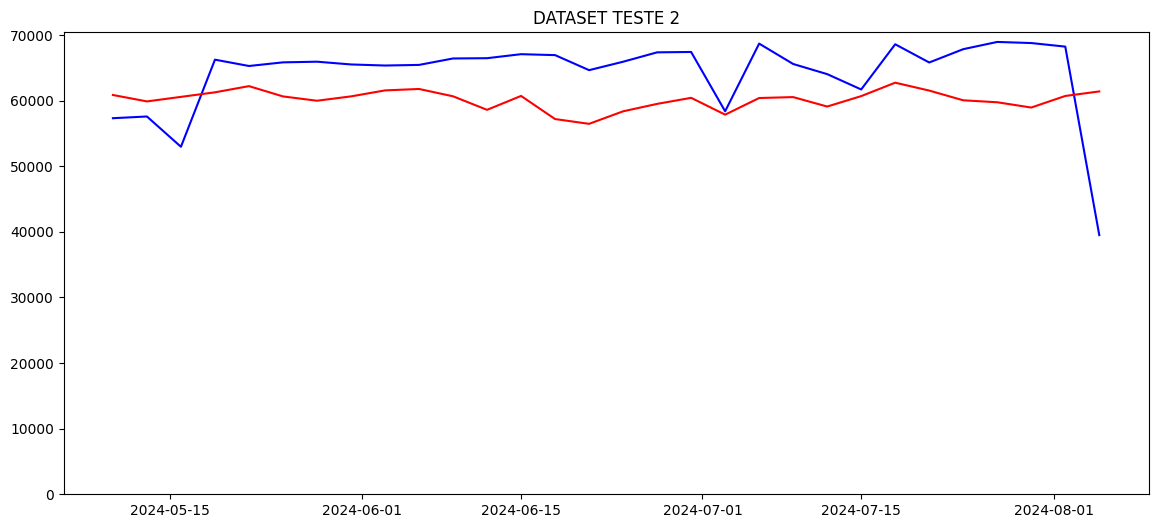

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.2.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.6795 - val_loss: 0.1115
Epoch 2/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1634 - val_loss: 0.1064
Epoch 3/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1499 - val_loss: 0.1071
Epoch 4/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1469 - val_loss: 0.1119
Epoch 5/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1336 - val_loss: 0.1064
Epoch 6/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1323 - val_loss: 0.1049
Epoch 7/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1247 - val_loss: 0.1067
Epoch 8/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1216 - val_loss: 0.1046
Epoch 9/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1254 - val_loss: 0.1046
Epoch 10/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1213 - val_loss: 0.1069
Epoch 11/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1198 - val_loss: 0.1048
Epoch 12/100000
25/25 ━━━

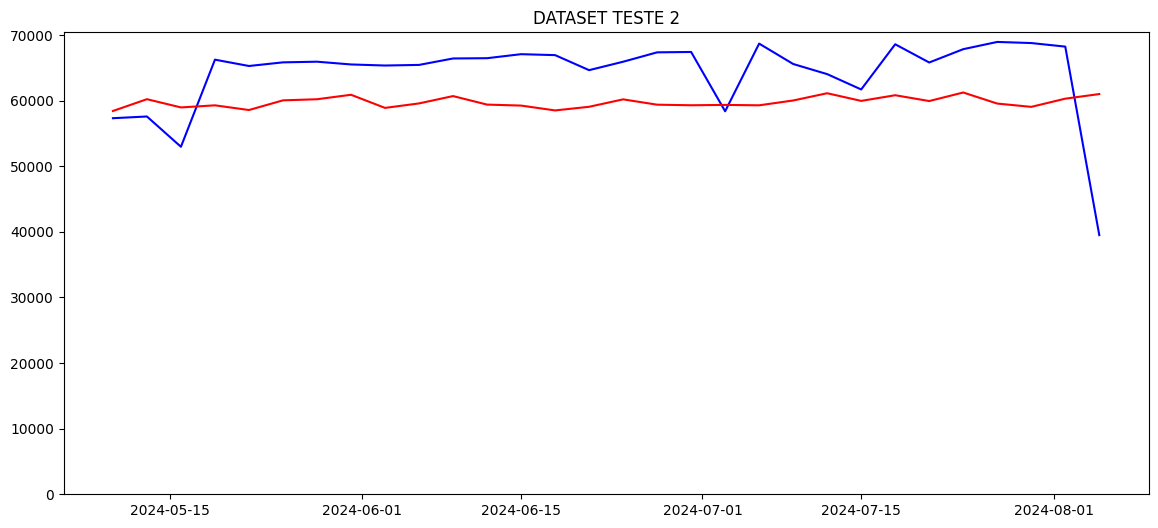

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.30000000000000004.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 422ms/step - loss: 0.7084 - val_loss: 0.1422
Epoch 2/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1729 - val_loss: 0.1343
Epoch 3/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1679 - val_loss: 0.1281
Epoch 4/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1527 - val_loss: 0.1145
Epoch 5/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1450 - val_loss: 0.1199
Epoch 6/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1406 - val_loss: 0.1268
Epoch 7/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1375 - val_loss: 0.1467
Epoch 8/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1440 - val_loss: 0.1159
Epoch 9/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1304 - val_loss: 0.1255
Epoch 10/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1270 - val_loss: 0.1220
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 4.
1/1 ━━━━━━━━━━━━━━━━━━━

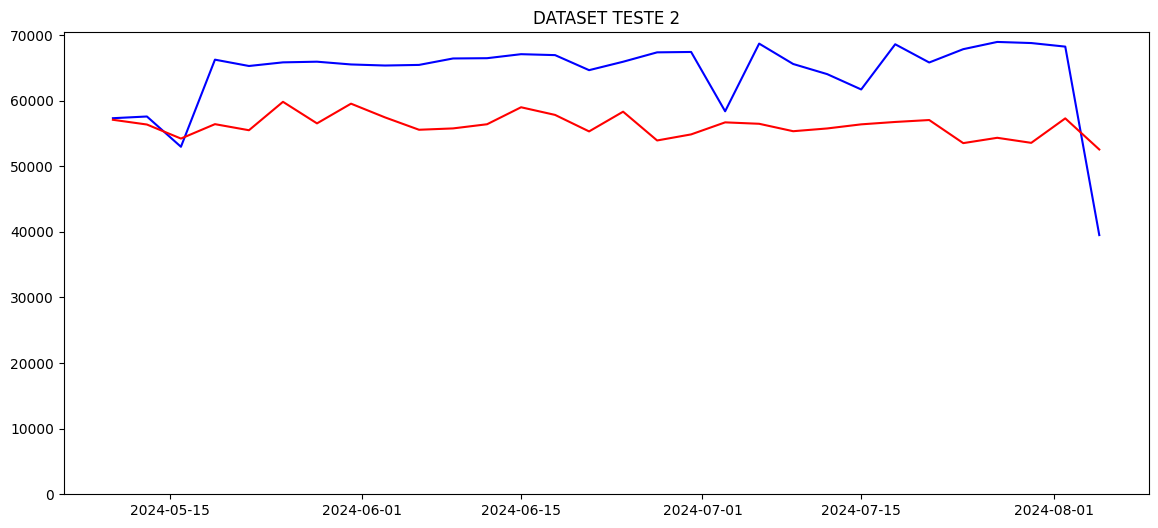

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.4.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 136ms/step - loss: 0.7408 - val_loss: 0.1378
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1775 - val_loss: 0.1117
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1645 - val_loss: 0.1086
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1581 - val_loss: 0.1060
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1421 - val_loss: 0.1090
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1448 - val_loss: 0.1153
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1389 - val_loss: 0.1067
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1365 - val_loss: 0.1137
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1297 - val_loss: 0.1066
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1270 - val_loss: 0.1055
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1260 - val_loss: 0.1053
Epoch 12/100000
1

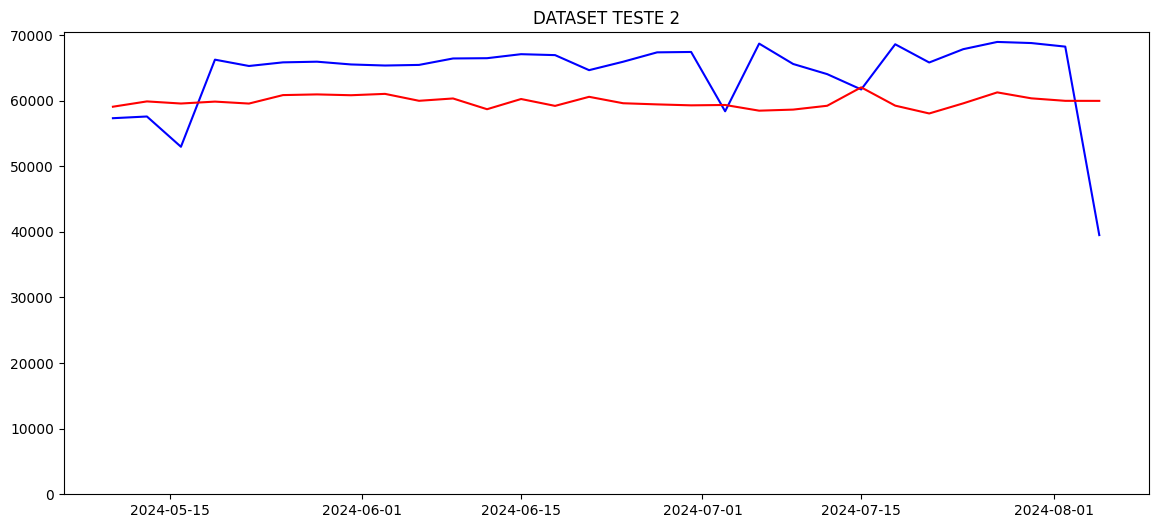

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.5.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - loss: 0.7619 - val_loss: 0.2534
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2046 - val_loss: 0.1173
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1601 - val_loss: 0.1277
Epoch 4/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1609 - val_loss: 0.1116
Epoch 5/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1466 - val_loss: 0.1165
Epoch 6/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1474 - val_loss: 0.1234
Epoch 7/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1423 - val_loss: 0.1127
Epoch 8/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1375 - val_loss: 0.1596
Epoch 9/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.1371 - val_loss: 0.1130
Epoch 10/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1323 - val_loss: 0.1120
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 4.
1/1 ━━━━━━━━━━━━━━━━━━━

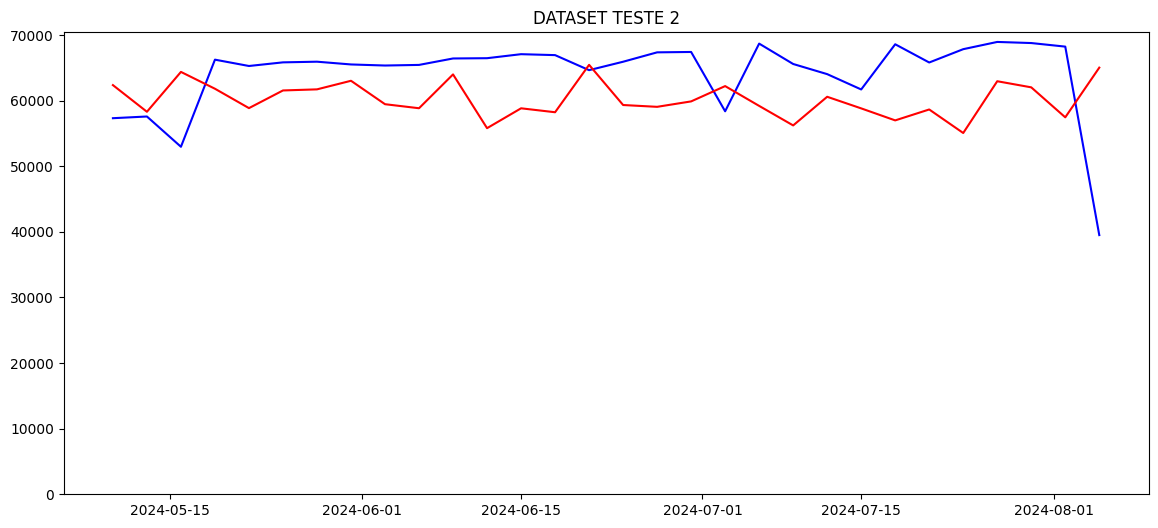

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.6.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - loss: 0.7945 - val_loss: 0.6348
Epoch 2/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.4941 - val_loss: 0.1343
Epoch 3/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1724 - val_loss: 0.1180
Epoch 4/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1522 - val_loss: 0.1258
Epoch 5/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1643 - val_loss: 0.1258
Epoch 6/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1537 - val_loss: 0.1193
Epoch 7/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1455 - val_loss: 0.1141
Epoch 8/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1409 - val_loss: 0.1068
Epoch 9/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1368 - val_loss: 0.1066
Epoch 10/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1436 - val_loss: 0.1078
Epoch 11/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1313 - val_loss: 0.1071
Epoch 12/100000
1

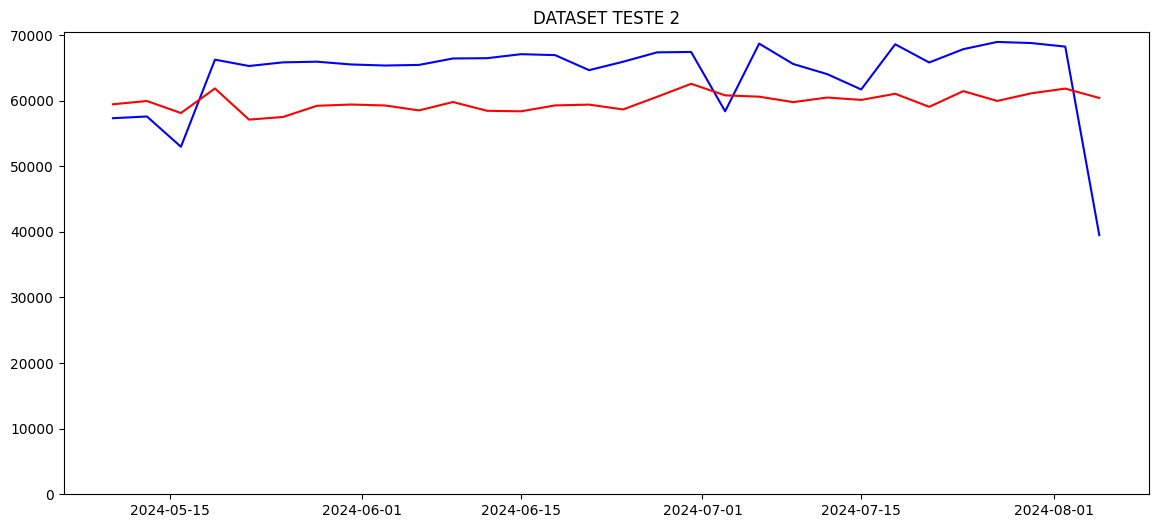

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.7.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_45 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_46 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - loss: 0.7929 - val_loss: 0.6897
Epoch 2/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.6157 - val_loss: 0.2171
Epoch 3/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2024 - val_loss: 0.1259
Epoch 4/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1724 - val_loss: 0.1400
Epoch 5/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1650 - val_loss: 0.1195
Epoch 6/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1604 - val_loss: 0.1174
Epoch 7/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1565 - val_loss: 0.1444
Epoch 8/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1564 - val_loss: 0.1491
Epoch 9/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1543 - val_loss: 0.1142
Epoch 10/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1619 - val_loss: 0.1282
Epoch 11/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1501 - val_loss: 0.1178
Epoch 12/100000
8/8 ━━━━━━━━━━━━━━━━━━━━

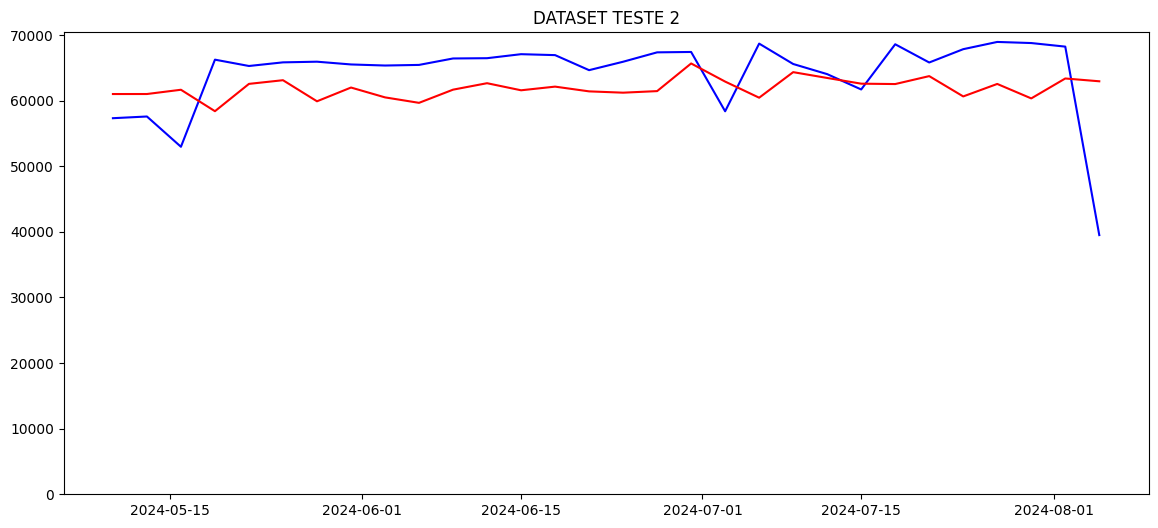

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.7999999999999999.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - loss: 0.8065 - val_loss: 0.7670
Epoch 2/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.7431 - val_loss: 0.6978
Epoch 3/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.6676 - val_loss: 0.5683
Epoch 4/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5095 - val_loss: 0.2763
Epoch 5/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: 0.2574 - val_loss: 0.1622
Epoch 6/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1880 - val_loss: 0.1164
Epoch 7/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1786 - val_loss: 0.1091
Epoch 8/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1593 - val_loss: 0.1170
Epoch 9/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1802 - val_loss: 0.1200
Epoch 10/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1733 - val_loss: 0.1214
Epoch 11/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1668 - val_loss: 0.1064
Epoch 12/100000
4/4 ━━━━━━━━━━━━━━━━━━━

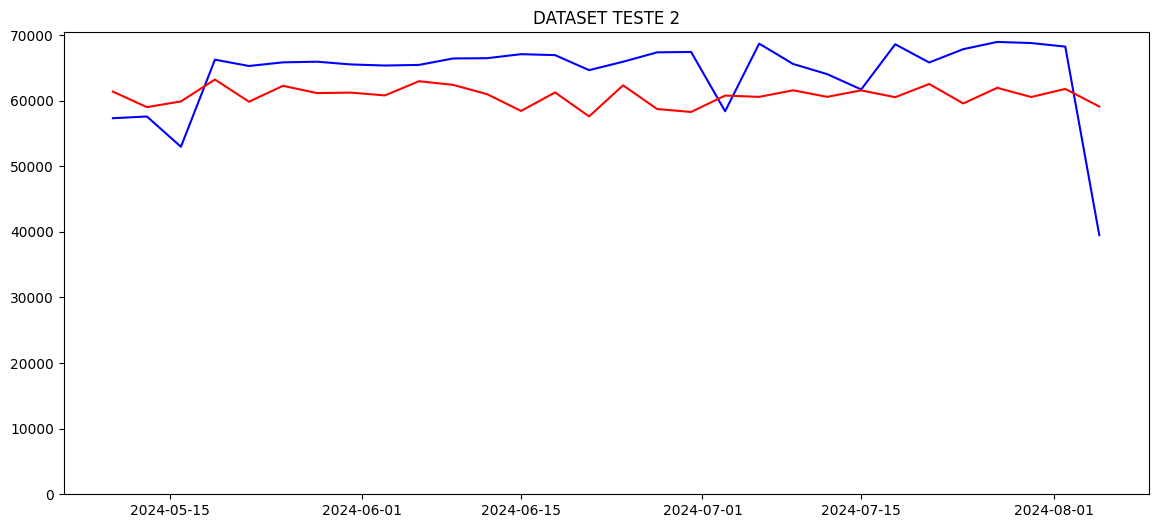

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.8999999999999999.txt


In [ ]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X, y = create_dataset(dataset_test_4, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

# for k in range(2,10):
#     model_4 = create_model(config, dataset_type_du, X, y, 'k-fold', k, 0)
#     results(model_4, duas_unas_validation_scaled, 'k-fold', diretorio_avaliacao_teste_4, k)

tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    model_4 = create_and_train_model(config, dataset_type_du, dataset_type_du, X, y, 'split', 0, tt_rate)
    results(model_4, duas_unas_validation_scaled, 'split', diretorio_avaliacao_teste_4, tt_rate)

#model_4 = create_model(config, dataset_type_du, X, y, validation_method, 5)